<a href="https://colab.research.google.com/github/bhagyoday-j/ML-Assignments/blob/main/AMLIS_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%html
<marquee style='width: 85%; color: blue;'><b> Applied Machine Learning for Industrial Solutions Lab  by Dr.T.Bhaskar  !</b></marquee>

In [ ]:
#STEP-1: Import Libraries
# Code to read csv file into colaboratory:
!pip install -U -q PyDrive
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 987.4/987.4 kB 38.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 183.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 10.5 MB/s eta 0:00:00


In [ ]:
#STEP-2: Autheticate E-Mail ID
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

In [ ]:
## IMPORT CSV FILES FROM DRIVE INTO GOOGLE-COLAB
downloaded = drive.CreateFile({'id':'1ooNkYk34ohWR1IRhUtvhJxq9nrno3brW'}) # replace the id with id of file you want to access
downloaded.GetContentFile('retail_sales_dataset.csv')
#https://drive.google.com/file/d/1ooNkYk34ohWR1IRhUtvhJxq9nrno3brW/view?usp=sharing

InvalidConfigError: Invalid client secrets file ('Error opening file', 'client_secrets.json', 'No such file or directory', 2)

In [ ]:
# Load dataset
import pandas as pd
data = pd.read_csv('retail_sales_dataset.csv')
print(data.shape)
print(data.head())
#print(data.describe())

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Load Dataset
df = pd.read_csv('retail_sales_dataset.csv')  # Update path as needed

# Inspect dataset
print("Dataset Preview:")
print(df.head())
print("\nDataset Info:")
print(df.info())

# Handle missing values
df['Age'] = df['Age'].fillna(df['Age'].mean())  # Numerical: Fill missing Age with mean
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())  # Numerical: Fill missing Quantity with median
df['Price per Unit'] = df['Price per Unit'].fillna(df['Price per Unit'].mean())  # Numerical: Fill missing Price with mean
df['Total Amount'] = df['Total Amount'].fillna(df['Quantity'] * df['Price per Unit'])  # Derive Total Amount if missing
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])  # Categorical: Fill missing Gender with mode
df['Product Category'] = df['Product Category'].fillna(df['Product Category'].mode()[0])  # Categorical: Fill missing Product Category with mode

# Verify no missing values
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# Normalize numerical features
scaler = MinMaxScaler()
numerical_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Visualizations using Matplotlib/Seaborn
plt.figure(figsize=(15, 10))

# Histogram of Total Amount
plt.subplot(2, 2, 1)
sns.histplot(df['Total Amount'], bins=30, kde=True, color='skyblue')
plt.title('Total Amount Distribution')

# Boxplot for Total Amount
plt.subplot(2, 2, 2)
sns.boxplot(y=df['Total Amount'], color='lightgreen')
plt.title('Total Amount Boxplot')

# Correlation heatmap for numerical columns
plt.subplot(2, 2, 3)
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')

# Monthly sales trend (line plot)
plt.subplot(2, 2, 4)
monthly_sales = df.groupby(df['Date'].dt.month)['Total Amount'].mean()
monthly_sales.plot(kind='line', marker='o', color='purple')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Average Total Amount')
plt.tight_layout()
plt.show()

# **Data Preprocessing/Claening - Google App Case Study**

In [ ]:
#STEP-1: Import Libraries
# Code to read csv file into colaboratory:
!pip install -U -q PyDrive
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

In [ ]:
#STEP-2: Autheticate E-Mail ID
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

In [ ]:
# Get File from Drive using file-ID
import pandas as pd
downloaded = drive.CreateFile({'id':'1fPF6AUNKWtfIQxXtp6X4-TPQIcTYqRGM'}) # replace the id with id of file you want to access
downloaded.GetContentFile('googleplaystore.csv')
# https://drive.google.com/file/d/1fPF6AUNKWtfIQxXtp6X4-TPQIcTYqRGM/view?usp=sharing  (Dataset Downloads Link)


data = pd.read_csv('googleplaystore.csv')
data


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Print first 5 Rows only
data.head(5)

In [ ]:
# Print all the columns name
print(data.columns)

In [ ]:
# Print the Data Types of Each column
data.dtypes

In [ ]:
data.shape

In [ ]:
data.describe()

In [ ]:
data.boxplot()

In [ ]:
data.hist()

In [ ]:
data.info()

In [ ]:
# prepocessing steps
data.isnull().sum()

In [ ]:
data[data.Rating > 5]

In [ ]:
data.drop([10472],inplace=True)

In [ ]:
data[10470:10475]

In [ ]:
data.boxplot()


In [ ]:
data.shape

In [ ]:
# Find the missing values in Each Column:
data.isnull().sum()

In [ ]:
# Find the missing values from Rating Column and repalce by Median value
# user Defined function
def impute_median(series):
    return series.fillna(series.median())

# Apply user defined function into Rating Column:
data.Rating=data['Rating'].transform(impute_median)

In [ ]:
# See the Rating Column Values
data[23:24]


In [ ]:
# See the Rating Column Values
data[113:114]

In [ ]:
data.isnull().sum()

In [ ]:
print(data['Type'].mode())

In [ ]:
print(data['Current Ver'].mode())


In [ ]:
print(data['Android Ver'].mode())

In [ ]:
# Find the Null values from Type Column and Replace by Mode
# mode :Value or a number that appears most frequently in a data set is a Mode
data['Type'].fillna(str(data['Type'].mode().values[0]),inplace=True)

In [ ]:
data[9148:9149]

In [ ]:
# Find the Null values from Current Ver Column and Replace by Mode
# mode :Value or a number that appears most frequently in a data set is a Mode
data['Current Ver'].fillna(str(data['Current Ver'].mode().values[0]),inplace=True)

In [ ]:
data[1553:1554]

In [ ]:
# # Find the Null vaues from Andtroid Ver Column and Replace by Mode
# mode :Value or a number that appears most frequently in a data set is a Mode
data['Android Ver'].fillna(str(data['Android Ver'].mode().values[0]),inplace=True)

In [ ]:
data[10472:10473]

In [ ]:
# See that  No  Column has null Values
data.isnull().sum()


In [ ]:
data.dtypes

In [ ]:
# convert price and review and rating into numerical Column
data['Price']=data['Price'].apply(lambda x: str(x).replace('$','')if '$' in str(x) else str(x))

In [ ]:
# See the Price Column Values
data[2171:2172]

In [ ]:
data['Price']=data['Price'].apply(lambda x: float(x))

In [ ]:
# See the Price Column Values
data[0:1]


In [ ]:
data.describe()

In [ ]:
data['Reviews']=pd.to_numeric(data['Reviews'],errors='coerce')
#Coercion is the implicit conversion of an instance of one type to another during an operation
#which involves two arguments of the same type. For example, in 3+4.5, each argument is of a different type (one int, one float),
#and both must be converted to the same type before they can be added or it will raise a TypeError.
#  >>> coerce(1, 1.5)
# (1.0, 1.5)
# >>> coerce(1 + 2j, 1)
# ((1+2j), (1+0j))

In [ ]:
data['Installs']=data['Installs'].apply(lambda x: str(x).replace('+','')if '+' in str(x) else str(x))

In [ ]:
data['Installs']=data['Installs'].apply(lambda x: str(x).replace(',','')if ',' in str(x) else str(x))
data['Installs']=data['Installs'].apply(lambda x: float(x))

In [ ]:
data[0:1]

In [ ]:
data.describe()

In [ ]:
data.describe()

In [ ]:
# Group the App Based on the Category
grp=data.groupby('Category')
x=grp['Rating'].agg(np.mean)

In [ ]:
result = sorted(x.items(), key=lambda x: x[1], reverse=True)[:5]
print
import operator
result1=dict(sorted(x.items(), key=operator.itemgetter(1), reverse=True)[:5])
print(x.max())
x.hist()

In [ ]:
x.hist()
y=grp['Price'].agg(np.sum)
result1 = sorted(y.items(), key=lambda x: x[1], reverse=True)[:5]

In [ ]:
print(result1)

In [ ]:
z=grp['Reviews'].agg(np.mean)
result2 = sorted(z.items(), key=lambda x: x[1], reverse=True)[:5]
print(z)

In [ ]:
print(result2)

In [ ]:
print(x)

In [ ]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.bar(x,y, color='g')
ax2.plot(x, y, 'b')
ax1.set_xlabel('Category')
ax1.set_ylabel('Price', color='g')
ax2.set_ylabel('Rating', color='b')
ax1.set_xticklabels(x,rotation='vertical',size=8)
plt.show()


In [ ]:
plt.figure(figsize=(16,5))
plt.plot(x,'r--',color='r')
plt.xticks(rotation=90)
plt.title("category wise rating")
plt.xlabel('Categories')
plt.ylabel('Rating')
plt.show()


In [ ]:
plt.figure(figsize=(16,5))
plt.plot(y,'r--',color='r')
plt.xticks(rotation=90)
plt.title("category wise rating")
plt.xlabel('Categories')
plt.ylabel('Price')
plt.show()


In [ ]:
plt.figure(figsize=(16,5))
plt.plot(z,'r--',color='b')
plt.xticks(rotation=90)
plt.title("category wise rating")
plt.xlabel('Categories')
plt.ylabel('Reviews')
plt.show()

# **ASSIGNMENT-2:SIMPLE LINEAR REGRESSION**


In [ ]:
#STEP-1: Import Libraries
# Code to read csv file into colaboratory:
!pip install -U -q PyDrive
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

In [ ]:
#STEP-2: Autheticate E-Mail ID
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

In [ ]:
## IMPORT CSV FILES FROM DRIVE INTO GOOGLE-COLAB
downloaded = drive.CreateFile({'id':'1ORTNkZgo6uc5VSYopHxl787fPdrs7-LT'}) # replace the id with id of file you want to access
downloaded.GetContentFile('SLR-Data.csv')
#https://drive.google.com/file/d/1ORTNkZgo6uc5VSYopHxl787fPdrs7-LT/view?usp=sharing

In [ ]:
#installation of python libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset
data = pd.read_csv('SLR-Data.csv')
print(data.shape)
print(data.head())
#print(data.describe())

# Collecting X and Y
X = data['No of Hours Spent During(X)'].values
Y = data['Risk Score on a scale of 0-100(Y)'].values

# Calculate Mean X and Y
mean_x = np.mean(X)
mean_y = np.mean(Y)
#print(mean_x)
#print(mean_y)
# Total number of values
m = len(X)
# Using the formula to calculate b1(slope) and b0(intercept)
numer = 0
denom = 0
for i in range(m):
    numer += (X[i] - mean_x) * (Y[i] - mean_y)
    denom += (X[i] - mean_x) ** 2
b1 = numer / denom
b0 = mean_y - (b1 * mean_x)

# Print coefficients:b1,b0
print("Slope,Intercept:",b1,b0)

# Plotting Values and Regression Line
max_x = np.max(X)
min_x = np.min(X)

# Calculating line values x and y
x = np.linspace(min_x, max_x)
y = b0 + b1 * x

# Ploting Line
plt.plot(x, y, color='green', label='Regression Line')
# Ploting Scatter Points
plt.scatter(X, Y, c='blue', label='Scatter Plot')
plt.xlabel('No of Hours Spent During')
plt.ylabel('Risk Score on a scale of 0-100')
plt.legend()
plt.show()

#For  Calculating Root Mean Squares Error
rmse = 0
for i in range(m):
    y_pred = b0 + b1 * X[i]
    rmse += (Y[i] - y_pred) ** 2
rmse = np.sqrt(rmse/m)
print("Root Mean Squares Error:",rmse)
# Calculating Accuracy Score
ss_t = 0
ss_r = 0
for i in range(m):
    y_pred = b0 + b1 * X[i]
    ss_t += (Y[i] - mean_y) ** 2
    ss_r += (Y[i] - y_pred) ** 2
r2 = 1 - (ss_r/ss_t)
print("Accuracy:",r2*100)
#predicting a o/p (y) for new value of x
predict_x=int(input('Enter No Hours Spent in Driving:'))
predict_y=(4.58789861*predict_x)+12.584627964022907
plt.scatter(X,Y)
plt.scatter(predict_x,predict_y)
plt.xlabel('No Hours Spent Driving(Predicted_x)')
plt.ylabel('Risk Score on a Scale of 0-100(Predicted_y)')
 #plotting the regression line
plt.scatter(X, Y, c='blue')
plt.plot(x, y, color='green')
# function to show plot
plt.show()

 **Assignment:2 Linear Regression for House Price Prediction** -  
Build and evaluate a linear regression model to predict house prices based
on size, location, number of rooms, and amenities. Evaluate the model.

In [ ]:
# House Price Prediction using Linear Regression

# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



In [ ]:
# Step 2: Create Dataset (Synthetic Example)
data = {
    'size': [1500, 1800, 2400, 3000, 3500, 4000, 1200, 1400, 2000, 2200],
    'location': [1, 2, 2, 3, 3, 1, 1, 2, 3, 1],  # Categorical encoded as integers
    'rooms': [3, 4, 3, 5, 4, 3, 2, 2, 4, 3],
    'amenities': [7, 8, 6, 9, 10, 7, 5, 6, 8, 7],
    'price': [300000, 350000, 450000, 500000, 600000, 420000, 250000, 280000, 480000, 390000]
}

df = pd.DataFrame(data)
display(df.head())



In [ ]:
# Step 3: Select Features and Target
X = df[['size', 'location', 'rooms', 'amenities']]
y = df['price']



In [ ]:
# Step 4: Split Data into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train values:\n", X_train)
print("X_test values:\n", X_test)

In [ ]:
# Step 5: Initialize and Train Model
model = LinearRegression()
model.fit(X_train, y_train)



In [ ]:
# Step 6: Make Predictions
y_pred = model.predict(X_test)

print("Predicted Prices:", y_pred)

In [ ]:
# Step 7: Evaluate Model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display Results
print("Actual Prices:", y_test.values)
print("Predicted Prices:", np.round(y_pred).astype(int))
print("Mean Squared Error (MSE):", mse)
print("R-squared (R2) Score:", r2)



In [ ]:
# Step 8 (Optional): Present in Table Form
results_df = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': np.round(y_pred).astype(int)
})
display(results_df)


In [ ]:
# Step 9: Visualize Results with Regression Line
plt.figure(figsize=(8, 6))
sns.regplot(x='Actual Price', y='Predicted Price', data=results_df, scatter_kws={'alpha':0.7}, line_kws={"color": "red"})
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices with Regression Line")
plt.grid(True)
plt.show()

**Lab Assignment:3 Classification of Loan Applications Using Logistic Regression** -  Train a logistic regression model to predict whether a loan application will
be approved or not based on applicant information. Evaluate using
confusion matrix, precision, recall, F1-score, and ROC-AUC.

In [ ]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)



In [ ]:
# Step 2: Load the Dataset
# Note: For some Google Drive links, you need to use a download link that starts with
# 'https://drive.google.com/uc?id=' + file_id
# If your link doesn't work, construct it as shown below

#file_id = '1tfTqckS7BhYZ2kd_Km1SuhpjXXPhk8ZE'
#url = f'https://drive.google.com/uc?id={file_id}'
#df = pd.read_csv(url)
url = 'https://drive.google.com/uc?export=download&id=1tfTqckS7BhYZ2kd_Km1SuhpjXXPhk8ZE'
df = pd.read_csv(url)
print(df.head)

In [ ]:
# Step 3: Remove leading/trailing spaces in column names
df.columns = df.columns.str.strip()
#strip() is a string method in Python that removes leading and trailing spaces from a string.
#Removes extra spaces in column names (e.g., " loan_amount " → "loan_amount")
#This avoids bugs when referencing column names later.

In [ ]:
# Step 4: View Dataset Info
print(df.info())
#Shows a summary of the dataset: number of rows, columns, data types, missing values.
print(df.head())
#shows the first 5 rows.

In [ ]:
# Step 5: Encode Categorical Columns
label_cols = ['education', 'self_employed', 'loan_status']
le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])
#Converts text data into numeric form because machine learning models need numbers.e.g., "Graduate" → 1, "Not Graduate" → 0


In [ ]:
# Step 6: Drop Irrelevant Columns
if 'loan_id' in df.columns:
    df.drop('loan_id', axis=1, inplace=True)
#Removes the loan_id column because it doesn't help with prediction — it’s just an identifier
print(df.info())

In [ ]:
# Step 7: Define Features and Target
X = df.drop('loan_status', axis=1)
y = df['loan_status']
#X: all columns used as input to the model (features).
#y: the column we want to predict — the target (loan_status).
print(X.head(2))
print(y.head())

In [ ]:
# Step 8: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Splits data into training (80%) and testing (20%) sets.
#Training data is used to build the model; testing data checks accuracy.
#print(X_train.head(1))
#print(X_test.head(1))
#print(y_train.head(1))
#print(y_test.head(1))
count_X_train = len(X_train)
count_X_test = len(X_test)
count_y_train = len(y_train)
count_y_test = len(y_test)
print("Number of Counts:count_X_train, count_X_test,count_y_train, count_y_test:", count_X_train, count_X_test,count_y_train, count_y_test)

In [ ]:
# Step 9: Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(X_train[0])  # first row of scaled training data
print(X_test[0])   # first row of scaled test data
#Standardizes the features to a common scale (mean=0, std=1).
#Helps the model converge faster and improve accuracy.


In [ ]:
print("Max per feature:\n", X_train.max())
print("Min per feature:\n", X_train.min())


In [ ]:
# Step 10: Train Logistic Regression Model
model = LogisticRegression()
model.fit(X_train, y_train)
#Creates and trains a Logistic Regression model to classify loan status (0 or 1).

In [ ]:
# Step 11: Predict and Evaluate
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(y_pred)
print(y_prob)
#y_pred: model’s predicted class (0 or 1) for test data.
#y_prob: predicted probability of loan being approved.

In [ ]:
count_pred = len(y_pred)
count_prob = len(y_prob)
print("Number of predictions:", count_pred, count_prob)

In [ ]:
# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
#A matrix that shows correct vs incorrect predictions.
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#AUC closer to 1 = better model.
# ROC Curve and AUC
roc_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Step 12: Keyboard Input for New Prediction

# Prompt user for input values (cast to correct types)
no_of_dependents = int(input("Enter number of dependents: "))
education = int(input("Enter Education (0 = Not Graduate, 1 = Graduate): "))
self_employed = int(input("Are you self-employed? (0 = No, 1 = Yes): "))
income_annum = int(input("Enter annual income: "))
loan_amount = int(input("Enter loan amount: "))
loan_term = int(input("Enter loan term (in years): "))
cibil_score = int(input("Enter CIBIL score: "))
residential_assets_value = int(input("Enter residential assets value: "))
commercial_assets_value = int(input("Enter commercial assets value: "))
luxury_assets_value = int(input("Enter luxury assets value: "))
bank_asset_value = int(input("Enter bank asset value: "))

# Create a new data point using the entered values
user_input = pd.DataFrame([{
    'no_of_dependents': no_of_dependents,
    'education': education,
    'self_employed': self_employed,
    'income_annum': income_annum,
    'loan_amount': loan_amount,
    'loan_term': loan_term,
    'cibil_score': cibil_score,
    'residential_assets_value': residential_assets_value,
    'commercial_assets_value': commercial_assets_value,
    'luxury_assets_value': luxury_assets_value,
    'bank_asset_value': bank_asset_value
}])

# Step 13: Scale the input just like training data
user_input_scaled = scaler.transform(user_input)

# Step 14: Predict using the trained model
pred_class = model.predict(user_input_scaled)[0]
pred_prob = model.predict_proba(user_input_scaled)[0][1]

# Step 15: Display results
print("\n📋 Input Summary:")
print(user_input)

print("\n✅ Prediction:")
print("Predicted Loan Status (0 = Denied, 1 = Approved):", pred_class)
print("Probability of Loan Approval:", f"{pred_prob:.2f}")

# **Summary of Steps:**

START

  │
  ├──▶ Step 1: Import Libraries

  ├──▶ Step 2: Load Dataset (from Google Drive)

  │
  ├──▶ Step 3: Clean Column Names (strip spaces)

  │
  ├──▶ Step 4: View Dataset Info (data types, missing values, preview rows)

  │
  ├──▶ Step 5: Encode Categorical Columns (Label Encoding)

  │
  ├──▶ Step 6: Drop Irrelevant Columns (e.g., loan_id)

  │
  ├──▶ Step 7: Define Features (X) and Target (y)

  │
  ├──▶ Step 8: Split Data (Train/Test = 80/20)

  │
  ├──▶ Step 9: Scale Features (StandardScaler)

  │
  ├──▶ Step 10: Train Model (Logistic Regression)

  │
  ├──▶ Step 11: Predict & Evaluate

  │       ├──▶ Predict test data (y_pred, y_prob)

  │       ├──▶ Classification Report

  │       ├──▶ Confusion Matrix

  │       └──▶ ROC Curve & AUC

  │
  ├──▶ Step 12–15: Take New Input (Keyboard)

  │       ├──▶ Scale new input

  │       ├──▶ Predict & Display result

  │
  └──▶ END


 # **4.Credit Risk Assessment in Banking (Model Evaluation Metrics)** -
**Develop a classification model to predict loan default using a real-world
financial dataset. Evaluate the model using accuracy, precision, recall, F1
score, confusion matrix, and ROC-AUC to environments.**

In [ ]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)


Loads the **German Credit dataset directly from UCI repository**.
It's used to predict whether someone is a good or bad credit risk—that is, whether they’re likely to default on a loan.

Total instances (rows): 1,000 people (applicants).

Features (columns): 20 different pieces of information (like age, credit history).

Target (label): 1 column indicating credit risk:

1 = Bad credit (default)

0 = Good credit (no default)

Assigns column names manually.

Target column: remapped from 1 → Good credit (0) and 2 → Bad credit (1) — **1 now means “loan default”.**

In [ ]:
# Step 2: Load Statlog (German Credit) Dataset from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
columns = [
    'Status_of_existing_checking_account', 'Duration_in_month', 'Credit_history',
    'Purpose', 'Credit_amount', 'Savings_account/bonds', 'Present_employment_since',
    'Installment_rate_in_percentage_of_disposable_income', 'Personal_status_and_sex',
    'Other_debtors/guarantors', 'Present_residence_since', 'Property',
    'Age_in_years', 'Other_installment_plans', 'Housing', 'Number_of_existing_credits',
    'Job', 'Number_of_people_being_liable_to_provide_maintenance_for',
    'Telephone', 'foreign_worker', 'Target'
]

df = pd.read_csv(url, delim_whitespace=True, header=None, names=columns)

# Convert target to binary: 1 = default (bad), 0 = good
df['Target'] = df['Target'].map({1: 0, 2: 1})

print("Data loaded successfully. Shape:", df.shape)
df.head()


get_dummies(): Converts categorical columns to numeric using one-hot encoding (needed for ML models).

StandardScaler(): Scales features so all values have mean 0 and std 1 — helps model convergence.

Train-test split: 80% for training, 20% for testing.

In [ ]:
# Step 3: Encode Categorical Variables and Scale
df_encoded = pd.get_dummies(df.drop('Target', axis=1), drop_first=True)
X = df_encoded
y = df['Target']


# Standard scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print("Train/Test split completed. X_train shape:", X_train.shape)


y_pred: predicted class (0 or 1)

y_prob: probability of being class 1 (default), used for ROC-AUC

In [ ]:
# Step 4: Train Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print(y_pred)
print(y_prob)

Accuracy: overall correct predictions

Precision: out of all predicted defaults, how many were real

Recall: out of all actual defaults, how many were caught

F1: harmonic mean of precision & recall

These give a balanced view, especially if the classes are imbalanced.

In [ ]:
# Step 5: Evaluation Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


In [ ]:
# Step 6: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Visual summary of prediction performance:

True Positives (TP): actual default predicted as default

True Negatives (TN): actual good predicted as good

False Positives (FP): predicted default, actually good

False Negatives (FN): predicted good, actually default



ROC curve shows tradeoff between true positive rate and false positive rate.

AUC (Area Under Curve): scalar measure of overall model performance.

AUC = 0.5 means random guessing; AUC = 1.0 means perfect classifier.

In [ ]:
# Step 7: ROC Curve and AUC
roc_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Step 8: Accept user input and predict
import sys

# Define input features in the same order as original data
input_dict = {
    'Status_of_existing_checking_account': input("Enter status of checking account (A11, A12, A13, A14): "),
    'Duration_in_month': int(input("Enter duration in months: ")),
    'Credit_history': input("Enter credit history (A30–A34): "),
    'Purpose': input("Enter purpose (A40–A49): "),
    'Credit_amount': float(input("Enter credit amount: ")),
    'Savings_account/bonds': input("Enter savings account status (A61–A65): "),
    'Present_employment_since': input("Enter employment status (A71–A75): "),
    'Installment_rate_in_percentage_of_disposable_income': int(input("Enter installment rate (1–4): ")),
    'Personal_status_and_sex': input("Enter personal status and sex (A91–A94): "),
    'Other_debtors/guarantors': input("Enter other debtors (A101–A103): "),
    'Present_residence_since': int(input("Enter years at current residence: ")),
    'Property': input("Enter property type (A121–A124): "),
    'Age_in_years': int(input("Enter age: ")),
    'Other_installment_plans': input("Enter other installment plans (A141–A143): "),
    'Housing': input("Enter housing (A151–A153): "),
    'Number_of_existing_credits': int(input("Enter number of existing credits: ")),
    'Job': input("Enter job (A171–A174): "),
    'Number_of_people_being_liable_to_provide_maintenance_for': int(input("Enter number of dependents: ")),
    'Telephone': input("Enter telephone status (A191 or A192): "),
    'foreign_worker': input("Is foreign worker? (A201 or A202): ")
}

# Convert to DataFrame
new_input_df = pd.DataFrame([input_dict])

# Combine with training data to handle one-hot encoding
combined_df = pd.concat([df.drop('Target', axis=1), new_input_df], ignore_index=True)

# One-hot encode
combined_encoded = pd.get_dummies(combined_df, drop_first=True)

# Align with training columns
missing_cols = set(X.columns) - set(combined_encoded.columns)
for col in missing_cols:
    combined_encoded[col] = 0

# Reorder columns
combined_encoded = combined_encoded[X.columns]

# Extract the last row (new input)
new_input_encoded = combined_encoded.tail(1)

# Scale input using trained scaler
new_input_scaled = scaler.transform(new_input_encoded)

# Check if model is defined before predicting
if 'model' not in locals():
    print("Error: The model has not been trained yet. Please run the previous steps first.")
else:
    # Predict
    predicted_class = model.predict(new_input_scaled)[0]
    predicted_prob = model.predict_proba(new_input_scaled)[0][1]

    # Output result
    print("\nPrediction:")
    if predicted_class == 1:
        print("❌ The model predicts: BAD CREDIT (HIGH RISK of default)")
    else:
        print("✅ The model predicts: GOOD CREDIT (LOW RISK of default)")

    print(f"Probability of default: {predicted_prob:.2f}")

**1. Status_of_existing_checking_account: A12**
What it means: The status of the applicant’s checking (current) account.

A11: No checking account

A12: Less than 0 DM (i.e., overdrawn or negative balance)

A13: 0 ≤ balance < 200 DM

A14: ≥ 200 DM or salary assignments

Interpretation:

A12 suggests this person’s checking account is overdrawn (negative balance) — not great, but not the worst.

**2. Duration_in_month: 24**
What it means: Duration of the requested loan — in months.

24 months = 2 years loan period.

Why it matters: Longer loans are generally riskier. But 2 years is moderate.

**3. Credit_history: A34**
What it means: Past credit behavior.

A30: No credit taken

A31: All credits paid back duly

A32: Existing credits paid back duly

A33: Delay in payments

A34: Critical account / other existing credit not paid back

Interpretation:

A34 is bad — it shows problems in the applicant’s past credit.

**4. Purpose: A43**
What it means: Why is the loan needed?

A40–A49 range includes purposes like: car, education, business, radio/TV, repairs, etc.

A43 might refer to domestic appliances (depending on the UCI mapping).

Interpretation: Neutral.

**5. Credit_amount: 3000**
What it means: Amount of loan being requested (in Deutsche Marks).

A moderate loan amount — not too high, not too small.

**6. Savings_account/bonds: A61**
What it means: Status of applicant’s savings account or investments.

A61: < 100 DM

A62: 100 ≤ … < 500

A63: 500 ≤ … < 1000

A64: ≥ 1000

A65: Unknown/No savings account

A61 = very low savings (< 100 DM). That’s a weak financial backup.

**7. Present_employment_since: A74**
What it means: How long the person has been employed.

A71: Unemployed

A72: < 1 year

A73: 1 ≤ … < 4 years

A74: 4 ≤ … < 7 years

A75: ≥ 7 years

A74 = 4–7 years of employment → stable job, a positive indicator.

**8. Installment_rate: 2**
What it means: The percentage of income used to repay the loan.

Range: 1 to 4 (1 = low, 4 = high)

2 = manageable loan payments → good.

**9. Personal_status_and_sex: A93**
What it means: Gender and marital status.

A91: male : divorced/separated

A92: female : divorced/separated/married

A93: male : single

A94: male : married/widowed

A93 = male and single. Might slightly impact risk depending on context.

**10. Other_debtors/guarantors: A101**
A101: None

A102: Co-applicant

A103: Guarantor

A101 = No one else is responsible → this person is solely responsible.

**11. Present_residence_since: 3**
How long they’ve lived at their current address (in years).

3 years = moderately stable.

**12. Property: A122**
What kind of property the person owns.

A121: Real estate

A122: Building society savings

A123: Car or other assets

A124: Unknown / no property

A122 = building society savings — decent asset.

**13. Age: 35**
Age of the applicant.

35 = mature adult, often a lower risk than very young borrowers.

**14. Other_installment_plans: A143**
Other loan plans.

A141: Bank

A142: Stores

A143: None

A143 = no other loan obligations — good.

**15. Housing: A152**
Type of housing.

A151: Rent

A152: Own

A153: For free

A152 = Own house — positive (assets increase creditworthiness).

**16. Number_of_existing_credits: 1**
Number of current loans or credits.

1 = Not too many obligations — good.

**17. Job: A173**
Job level.

A171: Unskilled

A172: Unskilled resident

A173: Skilled employee/official

A174: Management/self-employed/highly qualified

A173 = Skilled employee — good job stability.

**18. Number_of_dependents: 1**
Number of people financially dependent on the applicant (e.g., children, elderly).

1 dependent is manageable.

**19. Telephone: A191**
Telephone availability.

A191: Has a phone

A192: No phone

A191 = has a phone → better communication & traceability — positive.

**20. Foreign_worker: A201**
A201: Yes

A202: No

A201 = is a foreign worker → may be slightly higher risk in some cases depending on job type and legal standing.

**Model Output Summary:**
✅ The model predicts: GOOD CREDIT (LOW RISK of default)
📉 Probability of default: 0.08 (or 8%)

The applicant has some risk factors (e.g., overdrawn account, poor credit history, low savings).

But also has many positive signs:

Long employment

Owns housing

No other loans

Skilled job

Only one dependent

Reasonable age

Small loan amount

**Final Interpretation:**
Although the person has a few weak financial indicators, the overall profile is moderately strong, and the model concludes:

**They are likely to repay the loan, with a 08% probability of not defaulting.(No Risk)**.

 # **Example for BAD CREDIT RISK (uses risky) values like:**
No bank account

Unemployed

Long loan duration

High loan amount

Bad credit history

No phone

Renting house

Young age

Multiple dependents and debts

So, the model should predict:

❌ BAD CREDIT RISK with a high probability of default

## **5.Real-time Fraud Detection System (Model Deployment & Efficiency)** -
**Build and deploy a fraud detection model using logistic regression or
XGBoost. Implement the model as a RESTful API and evaluate its inference
time and memory usage under different loads.**

Installs all the Python packages we need like FastAPI (for API), XGBoost & scikit-learn (machine learning), pandas (data handling), matplotlib (plotting), and others.

The -q means "quiet" install (less output).

In [ ]:
!pip install -q fastapi uvicorn nest-asyncio pyngrok xgboost scikit-learn pandas matplotlib requests joblib gdown


**Imports all the libraries used in the program**.

Installs all the Python packages we need like FastAPI (for API), XGBoost & scikit-learn (machine learning), pandas (data handling), matplotlib (plotting), and others.

The -q means "quiet" install (less output). !pip install → installs external Python packages inside notebook/Colab.

-q → means quiet mode (less text output).

Packages installed:

fastapi → framework for building APIs.

uvicorn → lightweight web server to run FastAPI.

nest-asyncio → allows running async apps inside Jupyter/Colab.

pyngrok → creates a public URL for local apps (expose FastAPI online).

xgboost → ML algorithm (boosting trees).

scikit-learn → common ML library (Logistic Regression, preprocessing, metrics).

pandas → for dataset handling.

matplotlib → for graphs.

requests → to send HTTP requests to API.

joblib → save/load ML models.

gdown → download datasets from Google Drive.

tracemalloc to measure memory usage.

ThreadPoolExecutor to simulate multiple requests at the same time (concurrency).

In [ ]:
import nest_asyncio
from pyngrok import ngrok
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from fastapi import FastAPI, Request
from fastapi.responses import JSONResponse, FileResponse, HTMLResponse
import uvicorn
import joblib
import requests
from io import BytesIO
from PIL import Image
from IPython.display import display, Markdown
import threading
import time
import gdown
import tracemalloc
from concurrent.futures import ThreadPoolExecutor, as_completed


In [ ]:
# nest_asyncio allows running asynchronous code (like FastAPI) inside environments like Jupyter notebooks
import nest_asyncio

# pyngrok is used to create secure tunnels from your local server (like FastAPI) to the internet
from pyngrok import ngrok

# pandas is a powerful data manipulation library; used for loading, analyzing, and transforming data
import pandas as pd

# numpy is a numerical library used for working with arrays, matrices, and mathematical operations
import numpy as np

# train_test_split splits your dataset into training and testing sets for model evaluation
from sklearn.model_selection import train_test_split

# LogisticRegression is a simple machine learning model used for classification tasks
from sklearn.linear_model import LogisticRegression

# XGBClassifier is an efficient, high-performance gradient boosting classifier from the XGBoost library
from xgboost import XGBClassifier

# StandardScaler standardizes (scales) features so they have mean 0 and variance 1 — improves model performance
from sklearn.preprocessing import StandardScaler

# accuracy_score measures how often the model predicts the correct class — used for evaluating classification models
from sklearn.metrics import accuracy_score

# matplotlib is used for creating visualizations like plots and charts
import matplotlib.pyplot as plt

# FastAPI is a modern web framework used to build APIs quickly and efficiently
from fastapi import FastAPI, Request

# FastAPI response classes: return data in different formats like JSON, files, or HTML
from fastapi.responses import JSONResponse, FileResponse, HTMLResponse

# uvicorn is a web server used to run FastAPI applications
import uvicorn

# joblib is used to save and load trained machine learning models efficiently
import joblib

# requests allows your program to make HTTP requests (e.g., fetch data from APIs or websites)
import requests

# BytesIO lets you read/write binary data in memory — useful when dealing with images or files over the web
from io import BytesIO

# PIL (Python Imaging Library) is used for opening, manipulating, and saving image files
from PIL import Image

# display and Markdown are used in Jupyter notebooks to show rich output (formatted text, images, etc.)
from IPython.display import display, Markdown

# threading allows running multiple operations in parallel (multithreading)
import threading

# time module helps with operations like delays, measuring execution time, and working with timestamps
import time

# gdown allows you to download files directly from Google Drive programmatically
import gdown

# tracemalloc is used for tracking memory usage and detecting memory leaks in your Python program
import tracemalloc

# ThreadPoolExecutor is used to run functions in parallel threads; as_completed helps manage the results
from concurrent.futures import ThreadPoolExecutor, as_completed


**Download and load the Credit Card Fraud Detection dataset from Kaggle**:
I have download a real credit card fraud dataset from Google Drive using **gdown**.

Save it as a CSV file.

Load the CSV file into a pandas DataFrame df.

Print dataset shape (rows, columns) and first few rows to check data.

**file_id** → ID of dataset stored in Google Drive.

**download_url** → full link using file_id.

**csv_filename** → name to save locally.

**gdown.download** → download CSV from Google Drive.

**pd.read_csv** → read CSV into DataFrame.

**df.shape** → shows rows & columns.

**df.head()** → shows first 5 rows.

**Download dataset from Google Drive, load into Pandas DataFrame, and preview first few rows.**






In [ ]:
# -------- Step 1: Download and load real dataset --------
file_id = "1nmtDEUSWJvYlv6441QsFI4m-EgsLyG34"
download_url = f"https://drive.google.com/uc?id={file_id}"
csv_filename = "5.creditcard.csv"

print("Downloading dataset from Google Drive...")
gdown.download(download_url, csv_filename, quiet=False)

df = pd.read_csv(csv_filename)
print("Dataset shape:", df.shape)
print(df.head())

**Select features and target**
The target column is the label we want to predict (fraud or not). Usually named 'Class' here.

Separate features (X_all) and labels (y).

**Select only the first 10 numeric features (because we want 10 inputs)**.

Save feature names to feature_names for later use.
**Target column = "Class" (fraud = 1, normal = 0)**.
X_all → features (remove target column).

y → target labels.

X_numeric → select only numeric columns, pick first 10.

feature_names → list of feature names for later use.

**Extract fraud labels (target) and pick 10 numeric features as inputs for models.**

In [ ]:
# Determine target column
target_column = 'Class' if 'Class' in df.columns else 'fraud'
if target_column not in df.columns:
    raise ValueError(f"Target column '{target_column}' not found. Columns: {df.columns}")

# Select numeric features only, take first 10
X_all = df.drop(columns=[target_column])
y = df[target_column]

X_numeric = X_all.select_dtypes(include=np.number).iloc[:, :10]
feature_names = X_numeric.columns.tolist()
print(f"Using features ({len(feature_names)}): {feature_names}")
print(df.columns.tolist())

**Scale data and split into train/test**
Features are scaled to zero mean and unit variance using StandardScaler (improves ML training).

**Split data into training (70%) and testing (30%) sets, maintaining class distribution with stratify=y.**
StandardScaler → makes each feature mean=0, variance=1 → helps models converge faster.

train_test_split:

test_size=0.3 → 30% test, 70% train.

random_state=42 → reproducibility.

stratify=y → keep fraud/non-fraud ratio same.

**Scale features and split dataset into train/test while preserving fraud ratio.**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)
print(X_scaled)

**Train two ML models**
:Train Logistic Regression and XGBoost classifiers on training data.

Predict on test data.

Calculate and print accuracy for both models.
Train Logistic Regression & XGBoost on training data.

Predict & calculate accuracy.

Save models & scaler for deployment using joblib.dump.

**Train Logistic Regression & XGBoost, evaluate accuracies.**
This creates an instance of the LogisticRegression model from scikit-learn.

max_iter=1000: Sets the maximum number of iterations for the solver to converge. Sometimes Logistic Regression requires more iterations to find the optimal solution, especially on larger or complex datasets.

Uses the trained logistic regression model to predict labels for the test data X_test.

The predictions are stored in the variable log_pred.

Creates an instance of the XGBoost classifier from the xgboost library.

use_label_encoder=False: Disables label encoding that XGBoost used by default (this is to avoid warnings).

eval_metric='logloss': Sets the evaluation metric to log loss, which is suitable for binary classification problems.

**Prints the accuracy scores for both models.**

{log_acc:.4f} means the accuracy will be formatted to 4 decimal places.

In [ ]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
log_pred = log_reg.predict(X_test)
log_acc = accuracy_score(y_test, log_pred)

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)

print(f"Logistic Regression Accuracy: {log_acc:.4f}")
print(f"XGBoost Accuracy: {xgb_acc:.4f}")


**Save trained models and scaler**
:Save the trained models and scaler to files for loading later in API.

In [ ]:
joblib.dump(log_reg, "log_reg_model.pkl")
joblib.dump(xgb, "xgb_model.pkl")
joblib.dump(scaler, "scaler.pkl")


**Plot and save accuracy comparison graph**

Create a bar graph to visually compare model accuracies.

Save the plot as model_comparison.png.

Bar chart to compare model accuracies visually.

Save graph as "model_comparison.png".

**Create and save accuracy comparison graph.**

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(["Logistic Regression", "XGBoost"], [log_acc, xgb_acc], color=['blue', 'green'])
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.savefig("model_comparison.png")
plt.show()
plt.close()

print("Model Accuracy Comparison:")
print(f"Logistic Regression Accuracy: {log_acc:.4f}")
print(f"XGBoost Accuracy: {xgb_acc:.4f}")



**Create FastAPI app with routes**
:Homepage: HTML form to input features and select model.

Shows input boxes for each feature and model dropdown.

Links to graphs.

@app.get("/") → Defines homepage route (/).

Displays form with input boxes for each feature.

Dropdown to select model (Logistic Regression or XGBoost).

Links to accuracy & performance graphs.

**Create FastAPI homepage with HTML form for feature inputs + model selection.**

In [ ]:
app = FastAPI()

@app.get("/", response_class=HTMLResponse)
async def homepage():
    form_html = """
    <h2>Fraud Detection Prediction</h2>
    <form action="/predict" method="post">
    """ + "".join(
        [f'{feat}: <input type="number" step="0.0001" name="{feat}" required><br>' for feat in feature_names]
    ) + """
        <br>
        Select Model:
        <select name="model">
            <option value="log_reg">Logistic Regression</option>
            <option value="xgb">XGBoost</option>
        </select><br><br>
        <input type="submit" value="Predict">
    </form>
    <br>
    <a href="/comparison_graph">View Model Accuracy Comparison Graph</a><br>
    <a href="/performance_graph">View Inference Time & Memory Usage Comparison Graph</a>
    """
    return HTMLResponse(content=form_html)

**Prediction endpoint**: Takes input features and selected model, predicts fraud or not.

Reads form data, converts inputs to floats.

Loads scaler and scales input.

Loads selected model and makes prediction.

Returns JSON with result.

/predict endpoint → handles POST request from form.

Reads user inputs, converts to floats.

Loads scaler → scales inputs.

Loads selected model (log_reg or xgb).

Runs prediction:

1 → Fraudulent Transaction.

0 → Legitimate Transaction.

Returns result in JSON format.

**Add /predict API endpoint that takes inputs, scales them, loads model, and returns prediction in JSON.**

In [ ]:
@app.post("/predict", response_class=JSONResponse)
async def predict(request: Request):
    form = await request.form()
    try:
        features = [float(form[feat]) for feat in feature_names]
    except Exception as e:
        return JSONResponse({"error": f"Invalid input: {e}"})

    model_name = form.get("model", "log_reg")
    scaler = joblib.load("scaler.pkl")
    features_scaled = scaler.transform([features])

    if model_name == "log_reg":
        model = joblib.load("log_reg_model.pkl")
    else:
        model = joblib.load("xgb_model.pkl")

    prediction = model.predict(features_scaled)[0]
    result = "Fraudulent Transaction" if prediction == 1 else "Legitimate Transaction"

    return {"prediction": result, "model_used": model_name}


**Graph serving endpoints:**

Serve the saved accuracy and performance graphs as images.

/comparison_graph → returns saved accuracy comparison image.

/performance_graph → returns performance comparison image.

**Add endpoints to serve accuracy and performance graphs.**

In [ ]:
@app.get("/comparison_graph")
async def comparison_graph():
    return FileResponse("model_comparison.png")

@app.get("/performance_graph")
async def performance_graph():
    return FileResponse("performance_comparison.png")


**Performance test** - Measure inference time and memory usage under load
Helper function to measure single inference time:

Starts timer before prediction.

Runs prediction once.

Returns time taken.

**Helper function to calculate how long a single model prediction takes.**

In [ ]:
def measure_inference_time(model, features_scaled):
    start_time = time.time()
    _ = model.predict(features_scaled)
    return time.time() - start_time


**Function to simulate** many inference requests concurrently and measure average time & memory:

Uses Python’s tracemalloc to track memory usage during concurrent predictions.

Runs num_requests predictions with concurrency threads.

Returns average inference time and memory increase during load.

**num_requests=100** → simulate 100 requests.

**concurrency=10** → run 10 at the same time (parallel).

**tracemalloc** → measures memory usage.

Returns average inference time and memory increase.

**Load test models by simulating many requests and measure average inference time + memory increase.**


In [ ]:
def load_test_model(model, features_scaled, num_requests=100, concurrency=10):
    times = []

    tracemalloc.start()
    baseline_mem = tracemalloc.get_traced_memory()[0] / (1024 ** 2)  # baseline memory in MB

    def task():
        t = measure_inference_time(model, features_scaled)
        return t

    with ThreadPoolExecutor(max_workers=concurrency) as executor:
        futures = [executor.submit(task) for _ in range(num_requests)]
        for future in as_completed(futures):
            times.append(future.result())

    current_mem = tracemalloc.get_traced_memory()[1] / (1024 ** 2)  # max memory used in MB
    tracemalloc.stop()

    avg_time = sum(times) / len(times)
    mem_increase = current_mem - baseline_mem
    return avg_time, mem_increase


**Run tests for both models:**

Creates two bar charts side by side:

Inference time comparison.

Memory usage increase comparison.

Saves as "performance_comparison.png".

**Save performance comparison graph showing time & memory usage.**

In [ ]:
sample_feature_scaled = X_test[0].reshape(1, -1)

avg_logreg_time, mem_logreg = load_test_model(log_reg, sample_feature_scaled)
avg_xgb_time, mem_xgb = load_test_model(xgb, sample_feature_scaled)


In [ ]:
# Print results:
print(f"Logistic Regression - Avg inference time: {avg_logreg_time*1000:.3f} ms, Memory increase: {mem_logreg:.4f} MB")
print(f"XGBoost - Avg inference time: {avg_xgb_time*1000:.3f} ms, Memory increase: {mem_xgb:.4f} MB")


**Plot performance comparison graph**

Creates two bar charts side by side:

Inference time comparison.

Memory usage increase comparison.

Saves as "performance_comparison.png".

**Save performance comparison graph showing time & memory usage.**

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.bar(['Logistic Regression', 'XGBoost'],
        [avg_logreg_time*1000, avg_xgb_time*1000],
        color=['blue','green'])
plt.ylabel("Average Inference Time (ms)")
plt.title("Inference Time Comparison")

plt.subplot(1,2,2)
plt.bar(['Logistic Regression','XGBoost'],
        [mem_logreg, mem_xgb],
        color=['blue','green'])
plt.ylabel("Memory Usage Increase (MB)")
plt.title("Memory Usage Increase During Load")

plt.tight_layout()

# Save BEFORE show
plt.savefig("performance_comparison.png", dpi=300, bbox_inches="tight")

plt.show()
plt.close()

**Run FastAPI with ngrok for public access**

Sets ngrok token to create a public URL for your local API server.

Set API port (8015).

Use ngrok token → creates public link.

Runs FastAPI using uvicorn server inside a separate thread.

nest_asyncio allows async event loops to run inside Jupyter/Colab.

**Start FastAPI server with ngrok, make API accessible via public link.**

In [ ]:
PORT = 8001
NGROK_AUTH_TOKEN = "339wkfydj9OIPbbqrRLXhCxhSRh_wTqMGrdT63yPRtaaCHAo"

nest_asyncio.apply()

ngrok.set_auth_token(NGROK_AUTH_TOKEN)

def run_uvicorn():
    uvicorn.run(app, host="0.0.0.0", port=PORT)

thread = threading.Thread(target=run_uvicorn, daemon=True)
thread.start()

# Wait until FastAPI starts
time.sleep(5)

public_url = ngrok.connect(PORT)
print("Public API URL:", public_url.public_url)


**Demo prediction and display graphs inline in Colab**

**Picks one sample input from test data**.

Displays the prediction response.

Fetches and displays the two saved graphs inline in the notebook.

Runs load test for both models.

Prints results (time in ms, memory in MB).

**Compare Logistic Regression vs XGBoost performance under load.**
**Demonstrate sending request to API and receiving fraud prediction result.**

In [ ]:
sample_features = X_test[0]
sample_features_list = sample_features.tolist()

print("Sample input features:")
print(dict(zip(feature_names, sample_features_list)))

form_data = {feat: str(sample_features_list[i]) for i, feat in enumerate(feature_names)}
form_data["model"] = "log_reg"

predict_url = f"{public_url.public_url}/predict"

print("\nSending prediction request to API...")

response = requests.post(predict_url, data=form_data)
result_json = response.json()

print("Prediction API response:")
display(Markdown(f"**Prediction:** {result_json.get('prediction')}  \n**Model Used:** {result_json.get('model_used')}"))

# Display accuracy graph
graph_url = f"{public_url.public_url}/comparison_graph"
img_resp = requests.get(graph_url)
img = Image.open(BytesIO(img_resp.content))
print("\nModel Accuracy Comparison Graph:")
display(img)

# Display performance graph
perf_graph_url = f"{public_url.public_url}/performance_graph"
perf_img_resp = requests.get(perf_graph_url)
perf_img = Image.open(BytesIO(perf_img_resp.content))
print("\nInference Time & Memory Usage Comparison Graph:")
display(perf_img)


**Summary of Assignment**:

✔ Load real fraud dataset, preprocess, train 2 models (Logistic Regression & XGBoost models)

✔ Save models and scaler, plot accuracy graph.

✔ Build FastAPI app with endpoints:

. Homepage form

. Prediction endpoint

. Graph endpoints

✔ Performance testing with concurrency

 ✔ Plot inference time & memory usage graph

 ✔ Deploy FastAPI app with ngrok

 ✔ Deploy FastAPI app with ngrok


#  6.Customer Churn Prediction using Decision Tree Classifier -  
  **Develop a Decision Tree classifier to predict whether a telecom customer is likely to churn based on usage statistics (call duration, plan type, complaints, billing issues, etc.). Evaluate the model using accuracy, confusion matrix, and F1 score. Visualize the tree for interpretability.**

Goal: Build a **Decision Tree** classifier to predict whether a telecom customer will churn, and evaluate it using accuracy, confusion matrix, and F1-score. We'll also visualize the decision tree for interpretability.


**What you'll learn:**
- Load a real-world dataset from URLs
- Explore data and check class balance
- Preprocess data (impute missing values, One-Hot Encode categoricals)
- Train a Decision Tree using a `Pipeline`
- Evaluate with **Accuracy**, **F1-score**, **Confusion Matrix**
- Visualize the **Decision Tree** and **Feature Importances**
- Try simple **hyperparameter tuning** and visualize **Accuracy vs F1** across tree depths

**Dataset sources (mirrors):**
- Primary CSV (direct): `https://drive.google.com/file/d/1tVjkcy5vDKr6Nn9G2PBAaYlIyjyy4CnI/view?usp=drive_link

- Kaggle page (description): `https://www.kaggle.com/datasets/blastchar/telco-customer-churn`


In [ ]:

# ===== 1) Imports =====
# Standard data libraries
import pandas as pd       # Data manipulation (tables/dataframes)
import numpy as np        # Numerical computing (arrays, math)
import matplotlib.pyplot as plt  # Plotting (charts)

# Scikit-learn modules for modeling and evaluation
from sklearn.model_selection import train_test_split           # Split data into train/test
from sklearn.tree import DecisionTreeClassifier, plot_tree     # Decision Tree model + plotting
from sklearn.metrics import (                                  # Metrics to evaluate the model
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay,
    classification_report
)
from sklearn.compose import ColumnTransformer                  # Apply transforms by column type In machine learning:
from sklearn.preprocessing import OneHotEncoder                # Turn categoricals into 0/1 columns
from sklearn.pipeline import Pipeline                          # Chain preprocessing + model
from sklearn.impute import SimpleImputer                       # Fill missing values

# For reproducibility
RANDOM_STATE = 42           # Fixed seed so results are repeatable
np.random.seed(RANDOM_STATE)  # Set NumPy's random seed


**Need of ColumnTransformer:**
Numerical data often needs scaling (e.g., StandardScaler, MinMaxScaler)

Categorical data needs encoding (e.g., OneHotEncoder, OrdinalEncoder)

We can't apply the same transformer to all columns when they are of different types — ColumnTransformer solves this by allowing you to define transformations column-wise.

In [ ]:
# ===== 2) Load the dataset =====
# We'll try a few known mirrors for the IBM Telco Churn CSV.
# If one URL fails, we try the next so the notebook is robust.
# Load Dataset
url = 'https://drive.google.com/uc?export=download&id=1tVjkcy5vDKr6Nn9G2PBAaYlIyjyy4CnI'
df = pd.read_csv(url)
#df = pd.read_csv('6WA_Fn-UseC_-Telco-Customer-Churn.csv')  # Update path as needed
# Show basic shape (rows, columns) and first few rows
print('Shape:', df.shape)
display(df.head()) # Use display for better output in Colab

**Quick data check**
Inspect columns, types, missing values and class balance of the Churn column.

In [ ]:

# ===== 3) Quick data check =====
# info(): column names, non-null counts, and data types
print(df.info())

# Check target distribution (churn yes/no)
print("\nChurn value counts:")
print(df["Churn"].value_counts())

# Visualize class balance (bar chart)
plt.figure(figsize=(4,3))                      # Create a small figure
df["Churn"].value_counts().plot(kind="bar")   # Bar chart of class counts
plt.title("Target distribution (Churn)")      # Chart title
plt.xlabel("Churn")                           # X-axis label
plt.ylabel("Count")                           # Y-axis label
plt.show()                                    # Show the plot



## Preprocessing plan
- Drop identifier column `customerID` (not predictive)
- Convert `TotalCharges` to numeric (some rows may be blanks → NaN)
- Split into **features** `X` and **target** `y`
- Build a preprocessing `ColumnTransformer`:
  - **Numeric**: impute missing with median
  - **Categorical**: impute missing with most frequent, then One-Hot Encode
- Train/test split with stratification (preserves class balance)


In [ ]:

# ===== 4) Preprocess features =====
data = df.copy()   # Work on a copy so original df stays unchanged

# 4.1) Drop ID column if present (identifiers don't carry predictive signal)
if "customerID" in data.columns:
    data = data.drop(columns=["customerID"])  # Remove the 'customerID' column

# 4.2) Ensure TotalCharges is numeric (some rows may be blank strings -> NaN)
if "TotalCharges" in data.columns:
    data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")  # 'coerce' turns bad values into NaN

# 4.3) Target variable: map 'Yes'->1 and 'No'->0 (binary classification)
if data["Churn"].dtype == "object":
    y = (data["Churn"].str.strip()            # Remove leading/trailing spaces
                     .str.lower()             # Lowercase for consistent mapping
                     .map({"yes": 1, "no": 0}))  # Map strings to numbers
else:
    y = data["Churn"]

# 4.4) Features: all columns except 'Churn'
X = data.drop(columns=["Churn"])

# 4.5) Identify numeric & categorical columns based on data types
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()     # Columns with numbers
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist() # Columns that are not numeric

# 4.6) Define how to transform numeric columns: impute missing values with median
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# 4.7) Define how to transform categorical columns: impute most frequent and One-Hot Encode
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))  # ignore unseen categories at inference
])

# 4.8) Combine both into a ColumnTransformer so each type gets its own pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),  # Apply numeric pipeline to numeric columns
        ("cat", categorical_transformer, categorical_features),  # Apply categorical pipeline to categorical columns
    ]
)

# 4.9) Train/test split: 80% train, 20% test; stratify=y to keep same class ratio in both
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train.shape, X_test.shape  # Show shapes so we know the split sizes


**Train Decision Tree**
Create a Pipeline combining preprocessing and a DecisionTreeClassifier. Fit on training data.

Why: Pipeline ensures the same preprocessing is applied during training and future inference. max_depth constrains the tree for interpretability.

In [ ]:

# ===== 5) Train a Decision Tree =====
# We build a Pipeline that first preprocesses the data (imputing + one-hot), then trains the model.
# max_depth limits tree growth to improve interpretability and reduce overfitting.

clf = Pipeline(steps=[
    ("preprocess", preprocess),                                 # Our ColumnTransformer
    ("model", DecisionTreeClassifier(max_depth=5,               # Limit depth; try changing to see effects
                                     random_state=RANDOM_STATE))
])

# Fit the pipeline on training data (this runs preprocessing .fit/.transform then model .fit)
clf.fit(X_train, y_train)

print("Model trained successfully.")


In [ ]:
# ===== 5) Train a Decision Tree USING Entropy(Information Gain) =====
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

# Build the pipeline: preprocessing + decision tree model with entropy criterion
clf = Pipeline(steps=[
    ("preprocess", preprocess),                                 # Your ColumnTransformer
    ("model", DecisionTreeClassifier(max_depth=5,               # Limit depth
                                     criterion="entropy",       # Use entropy instead of gini
                                     random_state=RANDOM_STATE))
])

# Fit the pipeline on training data
clf.fit(X_train, y_train)

print("Model trained successfully.")


**Evaluate**
Predict on test set and compute Accuracy, F1-score, classification report, and plot confusion matrix.

Why: These metrics show model performance and where it makes mistakes (false positives/negatives). For churn detection, false negatives (missed churners) are often costly.

In [ ]:

# ===== 6) Evaluate the model =====
# Make predictions on the test set
y_pred = clf.predict(X_test)

# Compute common metrics
acc = accuracy_score(y_test, y_pred)     # Proportion of correct predictions
f1 = f1_score(y_test, y_pred)            # Balance between precision and recall

print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}")
print("\nClassification report:\n", classification_report(y_test, y_pred))

# Plot the confusion matrix to see TP/FP/FN/TN counts
plt.figure(figsize=(4,4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)  # Default style (no custom colors)
plt.title("Confusion Matrix (Decision Tree)")
plt.show()


**Visualize Decision Tree**
Extract the one-hot feature names and plot the top levels of the trained tree for interpretability.

Key idea: After One-Hot encoding, original categorical columns expand into many dummy features — we recover those names for labeling the tree.

In [ ]:

# ===== 7) Visualize the Decision Tree (top 3 levels) =====
# Because we use a Pipeline with One-Hot Encoding, we need to recover the expanded feature names.

# Access the trained DecisionTreeClassifier inside the pipeline
dt_model = clf.named_steps["model"]

# Access the fitted OneHotEncoder to get the names of new dummy columns
ohe = clf.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(categorical_features) if len(categorical_features) else np.array([])

# Combine original numeric feature names + one-hot categorical names
feature_names = np.r_[numeric_features, cat_names]

# Plot only top 3 levels to keep it readable
plt.figure(figsize=(20, 14))
plot_tree(
    dt_model,
    feature_names=feature_names,  # Names of features at each split
    class_names=["No", "Yes"],    # 0 -> No Churn, 1 -> Yes Churn
    max_depth=3,                  # Show top 3 levels of the tree
    filled=False,                 # Keep default styling (beginner-friendly)
    fontsize=8
)
plt.title("Decision Tree (Top 3 Levels)")
plt.show()


**criterion="gini"** (default): Measures impurity using the Gini index.

**criterion="entropy"**: Uses information gain (entropy) for splitting.

Both are valid, and **"entropy" tends to produce slightly different splits, sometimes deeper but more informative trees.**

Example:
Gini = 0 → Node is pure (only one class present)

Gini = 0.5 (binary case) → Perfectly mixed classes (e.g., 50% Yes, 50% No)

Gini closer to 1 → Very impure node

Suppose we have a node with:

70% "Yes" (class 1)

30% "No" (class 0)

Then:

Gini
=
1
−
(
0.7
)
2
−
(
0.3
)
2
=
1
−
0.49
−
0.09
=
0.42
Gini=1−(0.7)
2
−(0.3)
2
=1−0.49−0.09=0.42

Lower Gini is better. The decision tree algorithm chooses splits that minimize the Gini Impurity in child nodes.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# ----- Model with Gini (default) -----
clf_gini = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(max_depth=5, criterion="gini", random_state=RANDOM_STATE))
])
clf_gini.fit(X_train, y_train)
y_pred_gini = clf_gini.predict(X_test)

# ----- Model with Entropy -----
clf_entropy = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(max_depth=5, criterion="entropy", random_state=RANDOM_STATE))
])
clf_entropy.fit(X_train, y_train)
y_pred_entropy = clf_entropy.predict(X_test)

# ----- Evaluation -----
print("=== Gini Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_gini))
print(classification_report(y_test, y_pred_gini))

print("\n=== Entropy Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_entropy))
print(classification_report(y_test, y_pred_entropy))


**Simple Hyperparameter Tuning**
Use cross-validation to try several max_depth values and compare average F1 scores to pick a good depth.

Why F1: F1 balances precision and recall and is useful if classes are imbalanced or when both false positives and negatives matter.

In [ ]:

# ===== 8) Simple hyperparameter tuning =====
# Try various max_depth settings with cross-validation and compare F1-scores.

from sklearn.model_selection import cross_val_score

depths = [3, 4, 5, 6, 8, 10, None]  # 'None' means expand until pure leaves or min samples
cv_results = []

for d in depths:
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE))
    ])
    # Use 5-fold cross-validation; 'f1' focuses on the churn class balance
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="f1")
    cv_results.append((d, scores.mean()))
    print(f"max_depth={d}, mean F1 (cv=5): {scores.mean():.4f}")

# Best depth by average F1
best_depth, best_score = sorted(cv_results, key=lambda x: x[1], reverse=True)[0]
print(f"\nBest depth by CV (F1): {best_depth} with F1={best_score:.4f}")


In [ ]:

# ===== 9) Feature Importance Visualization =====
# Which features did the tree find most useful? Let's plot the top 15.

# Get importances from the trained DecisionTreeClassifier
importances = dt_model.feature_importances_

# Build a DataFrame linking feature names to importance values
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Keep the top 15 for clarity
top_features = importance_df.head(15)

# Plot (horizontal bar chart)
plt.figure(figsize=(10,6))
plt.barh(top_features["feature"], top_features["importance"])  # Horizontal bars
plt.gca().invert_yaxis()  # Highest importance at the top
plt.title("Top 15 Most Important Features (Decision Tree)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Show the table too
top_features


**Dashboard:** Accuracy vs F1, Top Features & Confusion Matrix
 Build combined plots that show model metric trade-offs over depths, most important features, and the confusion matrix together — great for teaching and quick reporting.

In [ ]:
## 10) Full Dashboard: Accuracy vs F1 + Top Features + Confusion Matrix

from sklearn.model_selection import cross_validate
from sklearn.metrics import ConfusionMatrixDisplay

# --- A) CV Accuracy & F1 across depths ---
depths = [3, 4, 5, 6, 8, 10, None]
cv_results = []

for d in depths:
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE))
    ])
    scores = cross_validate(pipe, X_train, y_train, cv=5,
                            scoring=["accuracy", "f1"], return_train_score=False)
    cv_results.append({
        "depth": "None" if d is None else d,
        "acc": scores["test_accuracy"].mean(),
        "f1": scores["test_f1"].mean()
    })

results_df = pd.DataFrame(cv_results)

# Convert 'depth' to categorical with ordered categories for correct plotting
results_df['depth_cat'] = pd.Categorical(results_df['depth'], categories=[d if d is not None else 'None' for d in depths], ordered=True)

# Create numerical representation for plotting (map 'None' to a value like -1)
results_df['depth_numeric'] = results_df['depth'].apply(lambda x: -1 if x == 'None' else x)

# --- B) Feature Importances from trained model ---
dt_model = clf.named_steps["model"]
ohe = clf.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(categorical_features) if len(categorical_features) else np.array([])
feature_names = np.r_[numeric_features, cat_names]

importances = dt_model.feature_importances_
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False).head(10)

# --- C) Predictions for Confusion Matrix ---
y_pred = clf.predict(X_test)

# --- D) Dashboard Plot ---
fig, axes = plt.subplots(1, 3, figsize=(20,6))

# 1) Accuracy vs F1
axes[0].plot(results_df["depth_numeric"], results_df["acc"], marker="o", label="Accuracy")
axes[0].plot(results_df["depth_numeric"], results_df["f1"], marker="s", label="F1-score")
axes[0].set_xlabel("Decision Tree max_depth")
axes[0].set_ylabel("Score")
axes[0].set_title("Cross-Validation: Accuracy vs F1-score")
axes[0].legend()
axes[0].grid(True)

# Set x-axis ticks and labels based on the original depths (including "None")
axes[0].set_xticks(results_df["depth_numeric"])
axes[0].set_xticklabels(results_df["depth"])


# 2) Top Features
axes[1].barh(importance_df["feature"], importance_df["importance"])
axes[1].invert_yaxis()
axes[1].set_title("Top 10 Important Features")
axes[1].set_xlabel("Importance")

# 3) Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[2], cmap="Blues")
axes[2].set_title("Confusion Matrix (Decision Tree)")

plt.tight_layout()
plt.show()

results_df, importance_df

In [ ]:
# ===== 9) Predict with Top 15 Important Features (Interactive + Demo) =====

# Toggle: set True for interactive input, False for demo mode
interactive = False
#interactive = True

print("Customer Churn Prediction using Top 15 Features")

# Top 15 features (from Decision Tree importance)
top_15_features = [
    "tenure", "Contract", "OnlineSecurity", "TechSupport", "InternetService",
    "MonthlyCharges", "PaymentMethod", "PaperlessBilling", "OnlineBackup",
    "DeviceProtection", "SeniorCitizen", "Partner", "Dependents",
    "StreamingTV", "StreamingMovies"
]

# Get the full list of features the model was trained on from the original X DataFrame
full_features = X.columns.tolist()

if interactive:
    print("\nInteractive Mode: Please enter values")
    input_features = {}
    for feature in top_15_features:
        value = input(f"Enter value for {feature}: ")
        # Simple type conversion based on expected types in X
        if feature in numeric_features: # Check if the feature is supposed to be numeric
            try:
                input_features[feature] = float(value)
            except ValueError:
                print(f"Invalid numeric input for {feature}, setting NaN by default.")
                input_features[feature] = np.nan # Use NaN for missing/invalid numeric input
        else: # Assume categorical for other top 15 features
            input_features[feature] = value
    user_input_data = input_features

else:
    print("\nDemo Mode: Using pre-filled sample inputs")
    sample_input = {
        "tenure": 12.0, # Ensure numeric types match
        "Contract": "Month-to-month",
        "OnlineSecurity": "No",
        "TechSupport": "No",
        "InternetService": "Fiber optic",
        "MonthlyCharges": 85.5,
        "PaymentMethod": "Electronic check",
        "PaperlessBilling": "Yes",
        "OnlineBackup": "No",
        "DeviceProtection": "No",
        "SeniorCitizen": 0.0, # Ensure numeric types match
        "Partner": "No",
        "Dependents": "No",
        "StreamingTV": "Yes",
        "StreamingMovies": "Yes"
    }
    user_input_data = sample_input


# Create a DataFrame with all original columns and their respective dtypes, initialized with NaN
user_df = pd.DataFrame(index=[0], columns=full_features)

# Populate the single row of the DataFrame with user/sample input for the top 15 features
for feature, value in user_input_data.items():
    if feature in user_df.columns:
        # Attempt to convert value to the target column's dtype if it's numeric
        if user_df[feature].dtype in [np.number, np.float64, np.int64]:
             try:
                user_df.loc[0, feature] = pd.to_numeric(value)
             except ValueError:
                 print(f"Warning: Could not convert input value for '{feature}' to numeric. Setting NaN.")
                 user_df.loc[0, feature] = np.nan
        else: # Assume object/categorical
            user_df.loc[0, feature] = value
    else:
        print(f"Warning: Feature '{feature}' from input is not in the original dataset.")

# The preprocessing pipeline includes imputation for both numeric and categorical columns.
# Missing values (NaN or None) in user_df for columns not in top_15_features,
# and potential NaNs from failed type conversion, will be handled by the imputer.

# Predict churn using trained pipeline
prediction = clf.predict(user_df)[0]

print("\n===== Prediction Result =====")
# Check if the prediction is 1 (churn) or 0 (no churn)
print("Customer is likely to CHURN." if prediction == 1 else "Customer is NOT likely to churn.")

**Why is F1-score often preferred over Accuracy for churn prediction?**

Imbalance issue: In churn datasets, usually more customers stay than churn.

If 90% don’t churn, a dumb model that predicts “No churn” always gets 90% accuracy but is useless.

F1-score balances:

Precision (how many predicted churns are correct)

Recall (how many actual churns were caught)

For business, missing a churner (false negative) is costly, so F1 helps keep both precision and recall in check.

👉 Note: **Accuracy may hide poor performance, while F1 gives a fairer evaluation in imbalanced churn prediction.**

# **Sample: Customer LIKELY to CHURN**

(Short tenure, month-to-month contract, high charges, no extra services)

sample_input_churn = {
    "tenure": 3,
    "Contract": "Month-to-month",
    "OnlineSecurity": "No",
    "TechSupport": "No",
    "InternetService": "Fiber optic",
    "MonthlyCharges": 95.0,
    "PaymentMethod": "Electronic check",
    "PaperlessBilling": "Yes",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "SeniorCitizen": 1,
    "Partner": "No",
    "Dependents": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes"
}



# **Sample: Customer NOT LIKELY to CHURN**

(Long tenure, yearly contract, lower charges, multiple services enabled)

sample_input_not_churn = {
    "tenure": 60,
    "Contract": "Two year",
    "OnlineSecurity": "Yes",
    "TechSupport": "Yes",
    "InternetService": "DSL",
    "MonthlyCharges": 45.0,
    "PaymentMethod": "Bank transfer (automatic)",
    "PaperlessBilling": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "Yes",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "Yes",
    "StreamingTV": "No",
    "StreamingMovies": "No"
}


# 📧 **7.Email Spam Detection using Naive Bayes**
**Build a Naive Bayes classifier to classify emails as spam or not spam based on email text (subject, body content, etc.). Apply text preprocessing (tokenization, stop word removal) and TF-IDF vectorization.**

**Goal:** Build a Naive Bayes classifier to classify emails as **spam** or **not spam** based on text (subject/body).  
We will:  
1. Load a dataset of emails  
2. Preprocess text (tokenization, stop word removal)  
3. Convert text → numeric features using **TF-IDF**  
4. Train a **Naive Bayes classifier**  
5. Evaluate model performance (accuracy, F1, confusion matrix)  
6. Test with new email samples  

---

**Dataset:**  
- Publicly available **SMS Spam Collection dataset** (can be used as proxy for email spam detection).  
- Direct TSV link:  
  `https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv`  

(Source: UCI Machine Learning Repository, hosted on GitHub)

**Dataset Download link** https://drive.google.com/file/d/1iTgjX4dXCe_C3eNfegfSymfLU7sX5QTJ/view?usp=sharing


In [ ]:
#  Importing required Python libraries

# pandas: Used for handling datasets (loading, exploring, cleaning, etc.)
import pandas as pd

# numpy: Provides mathematical functions and array operations
import numpy as np

# matplotlib: Used for creating visualizations such as graphs/plots
import matplotlib.pyplot as plt

# scikit-learn (sklearn) libraries for Machine Learning

# train_test_split: Splits dataset into training set and test set
from sklearn.model_selection import train_test_split

# TfidfVectorizer: Converts raw text into numerical features using TF-IDF
# (Term Frequency - Inverse Document Frequency)
from sklearn.feature_extraction.text import TfidfVectorizer

# MultinomialNB: Naive Bayes classifier suitable for text classification
from sklearn.naive_bayes import MultinomialNB

# Pipeline: Helps chain multiple ML steps together (e.g., vectorization + model training)
from sklearn.pipeline import Pipeline

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,          # Accuracy = (Correct predictions / Total predictions)
    f1_score,                # F1-score = balance between precision and recall
    ConfusionMatrixDisplay,  # Displays confusion matrix as a visual plot
    classification_report    # Provides precision, recall, F1-score for each class
)


## 1) Load the dataset

In [ ]:
#url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
#  URL of the dataset stored on Google Drive
# "uc?export=download&id=..." allows direct file download using file ID
url = 'https://drive.google.com/uc?export=download&id=1iTgjX4dXCe_C3eNfegfSymfLU7sX5QTJ'

#  Read the dataset using pandas
# - sep='\t' → means the file is tab-separated (TSV format)
# - header=None → dataset file does not have column headers, so we will assign them
# - names=["label", "message"] → renames the two columns:
#     "label" → spam/ham (spam=1, ham=0, or original text labels)
#     "message" → the email/SMS text content
df = pd.read_csv(url, sep='\t', header=None, names=["label", "message"])

#  Print the shape of the dataset
# Example: (5572, 2) → 5572 rows and 2 columns
print(df.shape)

#  Display the first 5 rows of the dataset
df.head()


## 2) Quick Data Exploration

In [ ]:
# Count how many 'spam' and 'ham' messages exist in the dataset
# value_counts() → counts frequency of each unique value in the "label" column
print(df["label"].value_counts())

# Plotting the class balance (how many spam vs ham messages)
plt.figure(figsize=(4,3))              # Set figure size (width=4, height=3)
df["label"].value_counts().plot(kind="bar")   # Create a bar chart of spam vs ham counts

# Add chart title and axis labels for clarity
plt.title("Distribution of Spam vs Ham (Not Spam)")
plt.xlabel("Label")       # X-axis = Spam / Ham categories
plt.ylabel("Count")       # Y-axis = Number of samples

# Show the bar chart
plt.show()




## 3) Preprocessing

- Convert text to lowercase  
- Tokenization (split into words)  
- Stop word removal  
- Transform into **TF-IDF vectors**  


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset (tab-separated)
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_table(url, header=None, names=["label", "message"])

# Encode labels: ham = 0, spam = 1
df["label"] = df["label"].map({"ham": 0, "spam": 1})

# Features and labels
X = df["message"]
y = df["label"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


In [ ]:
# Text Preprocessing + TF-IDF Vectorization

# Import TF-IDF vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Import NLTK (Natural Language Toolkit) for text processing
import nltk
from nltk.corpus import stopwords

# Download the stopwords list (common words like "the", "and", "is")
nltk.download("stopwords")

# Load English stopwords into a list
stop_words = stopwords.words("english")

#  Initialize the TF-IDF Vectorizer
# - stop_words=stop_words → remove common words that don’t add meaning
# - lowercase=True → convert all words to lowercase (to avoid treating "Hello" and "hello" differently)
tfidf = TfidfVectorizer(stop_words=stop_words, lowercase=True)

#  Convert raw text into TF-IDF feature vectors
# - fit_transform(X_train) → learn vocabulary from training data and transform it into numerical vectors
# - transform(X_test) → transform test data using the same vocabulary (no re-learning!)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

#  Print the shapes of the resulting matrices
# Each row = a message (sample), Each column = a word (feature)
print("Shape of TF-IDF matrix (train):", X_train_tfidf.shape)
print("Shape of TF-IDF matrix (test):", X_test_tfidf.shape)



In [ ]:
#  Pipeline: TF-IDF vectorizer -> MultinomialNB

# A Pipeline chains together multiple ML steps into one object.
# Here:
#   Step 1 ("tfidf") → Convert text into TF-IDF numerical features
#   Step 2 ("nb")    → Apply Naive Bayes classifier on those features

clf = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),  # preprocess text
    ("nb", MultinomialNB())                            # train classifier
])

# Train the pipeline using training data
# Internally:
#   - TfidfVectorizer first transforms X_train into a TF-IDF matrix
#   - Then MultinomialNB learns patterns between words and spam/ham labels
clf.fit(X_train, y_train)

#  Confirm model is trained
print("Model trained.")


## 5) Evaluate model

In [ ]:
# Step 1: Use the trained pipeline to make predictions
y_pred = clf.predict(X_test)
# - The pipeline will first run TF-IDF on X_test
# - Then use the Naive Bayes model to predict "spam" or "ham"

#  Step 2: Calculate Accuracy
acc = accuracy_score(y_test, y_pred)
# Accuracy = (correct predictions) / (total predictions)

#  Step 3: Calculate F1-score
f1 = f1_score(y_test, y_pred)
# F1 = Harmonic mean of Precision & Recall
# - Precision = Of all predicted spam, how many were actually spam?
# - Recall = Of all actual spam, how many did we catch?
# Useful when dataset is imbalanced (more ham than spam)

#  Step 4: Print results
print(f"Accuracy: {acc:.4f}")   # e.g. 0.97 → 97% correct
print(f"F1-score: {f1:.4f}")   # Balanced measure of spam detection quality

#  Step 5: Detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))
# Shows precision, recall, f1-score, and support (number of samples) for each class (spam & ham)

#  Step 6: Visualize confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix (Naive Bayes)")
plt.show()



## 6) Try with new examples

In [ ]:
#  Step 1: Create a few sample email messages
examples = [
    "Congratulations! You've won a $1000 Walmart gift card. Click here to claim.",  # Looks like spam
    "Hi John, are we still on for the meeting tomorrow at 10am?",                     # Looks like ham
    "Get cheap loans with zero interest now! Exclusive offer.",                      # Spam
    "Don't forget to bring the documents for our appointment."                       # Ham
]

#  Step 2: Predict labels for these new messages
# - The pipeline automatically applies TF-IDF + Naive Bayes
preds = clf.predict(examples)

#  Step 3: Print each message with its predicted label
for msg, label in zip(examples, preds):
    print(f"{label} -> {msg}")


**7). Word Cloud Visualization**

In [ ]:
# ✅ Import necessary libraries
from wordcloud import WordCloud          # For creating word clouds
import matplotlib.pyplot as plt          # For plotting images
import pandas as pd                      # Data handling (already used earlier)

# ✅ Step 1: Separate spam and ham messages
# Here we use the original 'message' column from df (before TF-IDF/vectorization)
# df["label"] == 1 → spam messages (using numerical label)
# df["label"] == 0 → ham messages (using numerical label)

spam_text = " ".join(df[df["label"] == 1]["message"])   # Concatenate all spam messages into one big string
ham_text  = " ".join(df[df["label"] == 0]["message"])   # Concatenate all ham messages into one big string

# ✅ Step 2: Generate Word Clouds
# WordCloud shows frequent words larger than rare ones
spam_wc = WordCloud(
    width=800, height=400,               # Canvas size
    background_color="black",            # Dark background
    colormap="Reds"                      # Red color scale
).generate(spam_text)

ham_wc = WordCloud(
    width=800, height=400,               # Canvas size
    background_color="white",            # Light background
    colormap="Blues"                     # Blue color scale
).generate(ham_text)

# ✅ Step 3: Plot word clouds side by side
plt.figure(figsize=(14,6))   # Create wide figure with two plots

# Left plot = Spam Word Cloud
plt.subplot(1,2,1)
plt.imshow(spam_wc, interpolation="bilinear")  # Show word cloud
plt.axis("off")                                # Hide axis
plt.title("Spam Emails Word Cloud")

# Right plot = Ham Word Cloud
plt.subplot(1,2,2)
plt.imshow(ham_wc, interpolation="bilinear")   # Show word cloud
plt.axis("off")                                # Hide axis
plt.title("Ham (Not Spam) Emails Word Cloud")

# Show both plots
plt.show()

# **8.Product Recommendation Category Classification using K-NN - Use KNN**
 to classify products into categories (e.g., electronics, clothing, books)
based on user ratings, reviews, and product metadata. Experiment with
different values of K and distance metrics


**Goal:** Use **K-Nearest Neighbors** to classify products into categories using text descriptions.

**Dataset (CSV):** `https://raw.githubusercontent.com/janhaslik/Ecommerce-Category-Classifier/main/ecommerceDataset.csv`


## 1) Setup

In [ ]:
# Libraries for data manipulation and visualization
import pandas as pd       # For working with tabular data (DataFrames)
import numpy as np        # For numerical operations
import matplotlib.pyplot as plt  # For plotting graphs

# Machine Learning libraries
from sklearn.model_selection import train_test_split, GridSearchCV  # For splitting data and tuning model
from sklearn.feature_extraction.text import TfidfVectorizer         # For converting text into numbers
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors # For KNN model and finding neighbors
from sklearn.pipeline import Pipeline                               # For chaining preprocessing + model
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report # For evaluation


## 2) Load the dataset

In [ ]:

DATA_URL = "https://raw.githubusercontent.com/janhaslik/Ecommerce-Category-Classifier/main/ecommerceDataset.csv"

# Try reading the dataset
try:
    df = pd.read_csv(DATA_URL)  # Load CSV into a DataFrame

    # Convert all column names to lowercase
    cols_lower = [c.lower() for c in df.columns]

    # Helper function: find the index of likely column (label/text)
    #It checks if any of the column names match known label or text column names.
    #It returns the index of the first match found from a set of possible names (e.g., label, category, etc.).

    def find_idx(options):
        for i, c in enumerate(cols_lower):
            if c in options:
                return i
        return None

    # Try to find index of label and text columns
    li = find_idx({'label','category','class','target'})
    ti = find_idx({'text','description','product_description','data','title','product name and description'})

    # If not found, use first two columns
    if li is None or ti is None:
        df = df.iloc[:, :2]
        df.columns = ['category','text']
    else:
        df = df.iloc[:, [li, ti]].copy()
        df.columns = ['category','text']

# If there's an error in loading, fallback to basic loading
except Exception:
    df = pd.read_csv(DATA_URL, header=None, names=['category','text'], encoding_errors='ignore', on_bad_lines='skip')

# Drop rows where category or text is missing
df = df.dropna(subset=['category','text']).copy()

# Clean text: make sure everything is string and stripped of spaces
df['text'] = df['text'].astype(str).str.strip()
df['category'] = df['category'].astype(str).str.strip()

# Show 5 random rows from the dataset
df.sample(5)


## 3) Quick EDA

In [ ]:

# Print shape of dataset
print("Shape:", df.shape)

# Show the most common categories (top 10)
print("\nClass distribution (top 10):\n", df['category'].value_counts().head(10))

# Show 2 sample texts from 6 different categories for understanding
examples = []
for cat in df['category'].unique()[:6]:
    subset = df[df['category'] == cat].head(2)  # Pick top 2 rows of that category
    for _, row in subset.iterrows():
        examples.append({'category': cat, 'text': row['text'][:160] + ("..." if len(row['text'])>160 else "")})
pd.DataFrame(examples)


## 4) Train / Test split

In [ ]:
# Split dataset into 80% training and 20% testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],          # Features (text)
    df['category'],      # Labels (category)
    test_size=0.2,       # 20% test data
    random_state=42,     # Reproducibility
    stratify=df['category']  # Maintain class balance
)
len(X_train), len(X_test)

## 5) TF-IDF + KNN with GridSearch (k, metric, weights)

In [ ]:
# Create a pipeline:
# 1. Convert text to TF-IDF features (bigrams included)
# 2. Use brute-force KNN
#Converts text into numeric features using TF-IDF.
#Removes common English stop words (like "the", "and", "in").
#Includes unigrams and bigrams (ngram_range=(1,2)).
#Ignores words/phrases that appear in less than 2 documents (min_df=2).
#A KNN classifier to predict product category.
#Uses brute-force search for finding nearest neighbors (good for small-medium datasets or sparse data).

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', ngram_range=(1,2), min_df=2)),
    ('knn', KNeighborsClassifier(algorithm='brute'))
])

# Define parameter grid to search
param_grid = {
    'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 15],          # Different k values
    'knn__metric': ['cosine', 'euclidean', 'manhattan'], # Distance metrics
    'knn__weights': ['uniform', 'distance']              # Weighting methods
}

# Grid Search with 3-fold cross-validation to find best parameters
grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring='f1_macro',   # Use F1 Macro (good for imbalanced classes)
    cv=3,
    n_jobs=-1,            # Use all available CPUs
    verbose=1,
    return_train_score=False
)
grid.fit(X_train, y_train)  # Train the grid search

# Print best model parameters
print("Best params:", grid.best_params_)
print("Best CV F1 (macro):", grid.best_score_)

# Save the best model
best_model = grid.best_estimator_


## 6) Validation curves: F1 vs k (per metric)

In [ ]:

res = pd.DataFrame(grid.cv_results_)  # All results

# Summarize performance by metric, k, and weight
summary = (res
           .groupby(['param_knn__metric','param_knn__n_neighbors','param_knn__weights'])['mean_test_score']
           .mean()
           .reset_index()
           .rename(columns={'param_knn__metric':'metric',
                            'param_knn__n_neighbors':'k',
                            'param_knn__weights':'weights',
                            'mean_test_score':'f1_macro'}))

# Find best weights for each metric
best_per_metric = (summary.sort_values('f1_macro', ascending=False)
                   .groupby('metric')
                   .head(1))[['metric','weights']]

# Plot F1 score vs k for each metric (with its best weight setting)
plt.figure()
for _, row in best_per_metric.iterrows():
    metric = row['metric']; weights = row['weights']
    sub = summary[(summary['metric']==metric) & (summary['weights']==weights)].sort_values('k')
    plt.plot(sub['k'], sub['f1_macro'], marker='o', label=f"{metric} (weights={weights})")

plt.xlabel('k')
plt.ylabel('CV F1 (macro)')
plt.title('Validation: F1 vs k for each distance metric')
plt.legend()
plt.grid(True)
plt.show()


## 7) Final Evaluation on the Test Set

In [ ]:

y_pred = best_model.predict(X_test)  # Predict on test set

# Evaluate using accuracy and macro F1 score
acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='macro')
print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1 (macro): {f1:.4f}\n")

# Detailed classification report (precision, recall, F1 per class)
print(classification_report(y_test, y_pred))

# Confusion Matrix
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

# Plot confusion matrix
plt.figure()
im = plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix (Test)')
plt.colorbar()
tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels, rotation=45, ha='right')
plt.yticks(tick_marks, labels)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()


## 8) Try it: Predict a category for your own product text

In [ ]:
def predict_category(texts):
    preds = best_model.predict(texts)  # Predict categories
    try:
        probs = best_model.predict_proba(texts)  # Try getting probabilities (if supported)
    except Exception:
        probs = None

    for i, t in enumerate(texts):
        print(f"\nText {i+1}: {t[:120]}{'...' if len(t)>120 else ''}")
        print(f"Predicted: {preds[i]}")
        if probs is not None:
            classes = list(best_model.named_steps['knn'].classes_)
            top_idx = np.argsort(probs[i])[::-1][:3]  # Top 3 predictions
            print("Top-3 probabilities:")
            for j in top_idx:
                print(f"  {classes[j]}: {probs[i][j]:.3f}")

# Try predicting some example texts
test_texts = [
    "Wireless Bluetooth over-ear headphones with noise cancellation and 30-hour battery.",
    "A heartwarming coming-of-age novel set in a small coastal town.",
    "Cotton crew-neck t-shirt for men with classic fit and soft feel.",
    "Stainless steel cookware set, non-stick frying pan and saucepans for everyday kitchen use."
]
predict_category(test_texts)


## 9)  Find similar products (Nearest Neighbours on TF-IDF)

In [ ]:

# Fit TF-IDF on training set again
vectorizer = best_model.named_steps['tfidf']
X_train_vec = vectorizer.fit_transform(X_train)

# Use NearestNeighbors with cosine similarity
nn = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute').fit(X_train_vec)

# Find similar items to a query
def show_similar(query_text, top_k=5):
    qv = vectorizer.transform([query_text])
    dists, idxs = nn.kneighbors(qv, n_neighbors=top_k+1)  # +1 because the first match is itself
    idxs = idxs[0].tolist()
    dists = dists[0].tolist()

    train_df = pd.DataFrame({'text': X_train, 'category': y_train}).reset_index(drop=True)
    print(f"Query: {query_text}\n")
    print("Similar products:")
    for i in range(1, min(len(idxs), top_k+1)):
        j = idxs[i]
        print(f"[{i}] ({train_df.loc[j, 'category']}) dist={dists[i]:.3f} -> {train_df.loc[j,'text'][:120]}...")

# Try it
show_similar("Bluetooth earbuds with charging case and touch controls", top_k=5)




## 10) Summary of Assignment:

We used KNN with TF-IDF vectorized text to classify product descriptions into categories.

We explored metrics, distance weights, and best k using GridSearchCV.

We evaluated the model with accuracy, F1-score, and confusion matrix.

We even predicted new samples and found similar products using NearestNeighbors.

 # 9.**Handwritten Digit Recognition using Support Vector Machine (SVM) - Train an SVM classifier on the MNIST dataset to recognize handwritten digits (0-9).**
 Perform hyperparameter tuning (kernel type, C value) and
evaluate performance using precision and recall


# ✍️ Handwritten Digit Recognition using **SVM** (MNIST)

In this Colab you will:
1. Load the **MNIST** dataset (60,000 train + 10,000 test of 28×28 digit images).
2. Preprocess: scale pixel values and **flatten** images into feature vectors.
3. Build an **SVM** pipeline (with `StandardScaler`).
4. Do **hyperparameter tuning** (kernel type, C, gamma for RBF) using `GridSearchCV` on a **training subset** (for speed).
5. Evaluate on a held-out test set using **precision**, **recall**, and **confusion matrix**.
6. Inspect **misclassified examples** and try predictions.

---

## 📦 Dataset
- **Keras MNIST** (auto-downloaded): `https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz`

If you need the classic OpenML version later: `fetch_openml("mnist_784")` (heavier/slow).

> ⚠️ Training a full RBF-SVM on all 60k images can be **slow**. We tune on a subset (e.g., 12k–20k) to keep runtime beginner-friendly, then evaluate on the test set.


## 1) Setup & imports

In [ ]:
# Installs the latest versions of scikit-learn (ML tools), matplotlib (plots), numpy (arrays), and tensorflow (to fetch MNIST dataset).
# (-q means quiet mode, suppresses detailed logs).
!pip install -q scikit-learn matplotlib numpy tensorflow

import numpy as np                    # For numerical computations and arrays
import matplotlib.pyplot as plt       # For plotting images and graphs
from sklearn.model_selection import train_test_split, GridSearchCV  # Splitting + hyperparameter tuning
from sklearn.preprocessing import StandardScaler   # For feature scaling
from sklearn.pipeline import Pipeline              # To combine preprocessing + model
from sklearn.svm import SVC                        # Support Vector Classifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.utils import shuffle                  # Shuffle dataset before subset selection
import tensorflow as tf                            # To load MNIST dataset
import random                                      # For reproducibility

# Fixing random seeds for reproducibility of results
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# 2) Load MNIST and peek at a few images
MNIST = 70,000 grayscale images (28×28 pixels) of handwritten digits 0–9

x_train → training images (60,000)

y_train → training labels (digits)

x_test → test images (10,000)

y_test → test labels

In [ ]:
# Load MNIST directly from Keras (downloads from: https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Train:", x_train.shape, y_train.shape) # (60000, 28, 28), (60000,)
print("Test :", x_test.shape, y_test.shape)   # (10000, 28, 28), (10000,)

# Show a small grid of first 12 training images with labels
fig, axes = plt.subplots(3, 4, figsize=(8, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()


## 3) Preprocess: scale to [0,1] and flatten to vectors

In [ ]:

# Scale pixel values to [0,1], then flatten 28x28 -> 784
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0
# Flatten 28x28 images → 784-dimensional vectors
n_train = x_train.shape[0]
n_test  = x_test.shape[0]
x_train_flat = x_train.reshape(n_train, -1)  # (60000, 784)
x_test_flat  = x_test.reshape(n_test, -1)    # (10000, 784)

print("Flattened shapes:", x_train_flat.shape, x_test_flat.shape)


## 4) Optional: Use a **subset** for hyperparameter tuning (keeps it fast)

In [ ]:

# Choose how many samples to use for GridSearchCV (increase if you have more time/compute)
SUBSET = 15000  # try 12000–20000 for reasonable speed in Colab
# Shuffle training data for randomness
x_train_flat, y_train = shuffle(x_train_flat, y_train, random_state=42)
# Take only first 15k samples
x_sub = x_train_flat[:SUBSET]
y_sub = y_train[:SUBSET]

print("Subset used for tuning:", x_sub.shape, y_sub.shape)


## 5) Build SVM pipeline + grid search (kernel, C, gamma)
Grid with conditional params:
- linear kernel: tune C
- rbf kernel: tune C and gamma

C: Regularization strength (smaller = simpler model, larger = stricter fit)

gamma: Spread of RBF kernel (small gamma = smoother decision boundary, large gamma = more complex)

GridSearchCV automatically tries all parameter combinations and picks the best model.

In [ ]:

from sklearn.utils.multiclass import unique_labels

# Pipeline: Standardize -> SVM
# StandardScaler centers features, which helps SVM. We use default (with_mean=True).
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC())
])


param_grid = [
    {"svc__kernel": ["linear"], "svc__C": [0.5, 1, 3]},       # Linear kernel → only tune C
    {"svc__kernel": ["rbf"],    "svc__C": [1, 3, 10], "svc__gamma": ["scale", 0.01]}  # RBF kernel → tune C + gamma
]

# Perform grid search with cross-validation
grid = GridSearchCV(
    estimator=svm_pipe,
    param_grid=param_grid,
    scoring="accuracy",   # Metric for evaluation
    cv=3,                 # 3-fold cross-validation
    n_jobs=-1,            # Use all CPU cores
    verbose=1,            # Show progress
    refit=True            # Retrain best model on full subset
)

# Fit on training subset
grid.fit(x_sub, y_sub)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)
best_model = grid.best_estimator_

## 6) Evaluate on the **test** set (precision & recall)

Precision = How many predicted digits are correct

Recall = How many actual digits were correctly found

F1 = Harmonic mean of precision & recall

In [ ]:

# Predict on the untouched test set
y_pred = best_model.predict(x_test_flat)

# Classification report (includes precision, recall, f1 for each digit + averages)
print(classification_report(y_test, y_pred, digits=4))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix — SVM on MNIST (test set)")
plt.tight_layout()
plt.show()


## 7) Inspect a few misclassified examples

In [ ]:

mis_idx = np.where(y_pred != y_test)[0]
print(f"Misclassified: {len(mis_idx)} examples")

# Show up to 12 misclassified examples
k = min(12, len(mis_idx))
if k > 0:
    fig, axes = plt.subplots(3, 4, figsize=(8, 6))
    for i, ax in enumerate(axes.flatten()[:k]):
        idx = mis_idx[i]
        ax.imshow(x_test[idx], cmap='gray')
        ax.set_title(f"True: {y_test[idx]} | Pred: {y_pred[idx]}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No misclassifications to display.")


## 8) Try it: Predict a few test images



In [ ]:

# Pick 5 random test images and predict
sample_idx = np.random.choice(len(x_test_flat), size=5, replace=False)
sample_imgs = x_test[sample_idx]
sample_vecs = x_test_flat[sample_idx]
sample_preds = best_model.predict(sample_vecs)

for i, idx in enumerate(sample_idx):
    plt.figure(figsize=(2.5, 2.5))
    plt.imshow(sample_imgs[i], cmap='gray')
    plt.title(f"Pred: {sample_preds[i]} | True: {y_test[idx]}")
    plt.axis('off')
    plt.show()


# Summary:

Loaded MNIST → Preprocessed (scale + flatten)

Built SVM pipeline → Tuned hyperparameters (GridSearchCV)

Evaluated with precision/recall + confusion matrix

Analyzed misclassifications

Tried predictions on random digits


# 10. Bias Detection & Fairness Evaluation in Hiring Algorithms

**Goal:** Use the UCI Adult Income dataset as a proxy for hiring decisions (predict whether income >50K) and:
- Train a classification model (Logistic Regression) for hiring decisions.
- Evaluate using traditional metrics (accuracy, F1) **and** fairness metrics (demographic parity, equal opportunity, equalized odds).
- Analyze bias across **gender (sex)** and **race**, and demonstrate two simple mitigation strategies: **reweighing (pre-processing)** and **group-specific thresholding (post-processing)**.

**Dataset (UCI Adult / "Census Income"):**
- Data: `https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data`
- Attribute information: `https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.names`

> Note: In this notebook we treat `income >50K` as the model's *positive* outcome (hiring/promotion/selection proxy).


## 1) Setup & imports

In [ ]:

# Install (uncomment in Colab if needed)
# !pip install -q scikit-learn pandas matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')


## 2) Load the UCI Adult dataset (Census Income)

In [ ]:

# Column names (from the dataset documentation)
columns = ["age","workclass","fnlwgt","education","education-num","marital-status",
           "occupation","relationship","race","sex","capital-gain","capital-loss",
           "hours-per-week","native-country","income"]

# URL to raw data
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

# Read dataset, treating ' ?' as NaN and skipping leading spaces
df = pd.read_csv(DATA_URL, header=None, names=columns, na_values=' ?', skipinitialspace=True)

print("Shape:", df.shape)
df.head(5)


## 3) Quick EDA & target preparation

Shows structure with df.info() and target distribution with value_counts().

Strips whitespace from income, removes rows with missing income, and maps '>50K' -> 1 and '<=50K' -> 0 into a numeric target.

Prints unique values for protected attributes sex and race.

**Why it matters**

Ensures the target is clean and numeric (required for ML models).

Quickly reveals class balance and what protected group labels look like.

In [ ]:

# Basic checks
print(df.info())
print("\nTarget distribution:")
print(df['income'].value_counts())

# Clean target: strip and map to 0/1
df['income'] = df['income'].str.strip()
df = df[df['income'].notna()].copy()
df['target'] = df['income'].map({'>50K':1, '<=50K':0})

print("\nAfter mapping, target counts:")
print(df['target'].value_counts())

# Protected attributes we'll analyze
print("\nProtected attribute values:")
print("Sex:", df['sex'].unique())
print("Race:", df['race'].unique())


## 4) Data cleaning & feature selection

Shows missing counts and drops rows with any missing values (df.dropna()).

Selects a subset of features (drops fnlwgt and the original string income).

Creates a protected_attributes DataFrame (sex, race) for later auditing.

**Why it matters**

Simplicity: dropping missing rows is easy to understand for beginners.

protected_attributes kept separately ensures the fairness code can access group labels aligned with X/y.

In [ ]:

# Drop rows with missing values for simplicity (or you can impute)
print('Missing values per column:\n', df.isna().sum())

# For this beginner notebook we will drop rows with missing values (simple and transparent).
df = df.dropna().reset_index(drop=True)
print('\nAfter dropna:', df.shape)

# Select features (drop fnlwgt and original income string column)
features = ["age","workclass","education-num","marital-status","occupation",
            "relationship","race","sex","capital-gain","capital-loss","hours-per-week","native-country"]
X = df[features].copy()
y = df['target'].copy()

# We'll keep 'sex' and 'race' as protected attributes (but they are also one-hot encoded for the model)
protected_attributes = pd.DataFrame({
    'sex': df['sex'].astype(str).str.strip(),
    'race': df['race'].astype(str).str.strip()
})

X.head(3)


## 5) Train/Validation/Test split

Splits data into train (60%), validation (20%), and test (20%) using train_test_split twice (first split out test, then split the remainder).

Uses stratify=y to preserve class balance across splits.

Splits protected attributes in parallel so group labels remain aligned.

**Why it matters**

Validation is used to tune thresholds (post-processing) without touching the test set.

Stratification avoids accidentally making training or test sets unbalanced on the target.

In [ ]:

# Split into train (60%), validation (20%), test (20%) to allow threshold tuning on validation
X_temp, X_test, y_temp, y_test, prot_temp, prot_test = train_test_split(
    X, y, protected_attributes, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val, prot_train, prot_val = train_test_split(
    X_temp, y_temp, prot_temp, test_size=0.25, random_state=42, stratify=y_temp
)  # 0.25 * 0.8 = 0.2

print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)


## 6) Preprocessing pipeline (numeric + categorical)

Defines numeric and categorical feature lists.

Numeric pipeline: impute missing with median, then StandardScaler.

Categorical pipeline: impute with most frequent value then OneHotEncoder(handle_unknown='ignore', sparse=False).

Combines with ColumnTransformer.

Builds full Pipeline that ends in LogisticRegression(solver='liblinear').

Fits the pipeline on training data.

**Why it matters**

Pipelines ensure the same preprocessing is applied to train/val/test consistently.

Logistic Regression outputs probabilities needed for thresholding.

In [ ]:
numeric_features = ['age','education-num','capital-gain','capital-loss','hours-per-week']
categorical_features = [c for c in features if c not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Full pipeline with Logistic Regression (probabilities needed for thresholding)
clf = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(solver='liblinear', max_iter=1000))
])

# Fit baseline model (no special weighting)
clf.fit(X_train, y_train)
print('Baseline model trained.')

## 7) Baseline evaluation (accuracy, F1)

Produces hard predictions (predict) and probabilities (predict_proba[:,1]) on the test set.

Prints accuracy, F1, and a classification report.

**Why it matters**

Establishes baseline performance (useful to compare after mitigation).

F1 is helpful when classes are imbalanced.

In [ ]:

# Predictions on test set
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]

print('Accuracy:', accuracy_score(y_test, y_pred))
print('F1-score:', f1_score(y_test, y_pred))
print('\nClassification report:\n', classification_report(y_test, y_pred))


## 8) Fairness metric helper functions

Implements selection_rate, true_positive_rate (TPR), false_positive_rate (FPR).

group_metrics computes these metrics per group and returns a DataFrame.

**Why it matters**

These functions are the building blocks for fairness checks:

Selection rate → demographic parity (do groups get positive outcomes at similar rates?)

TPR → equal opportunity (do groups of actually-positive examples get selected equally?)

FPR → helps measure equalized odds.

In [ ]:

def selection_rate(y_pred, group_mask):
    # P(pred=1 | group)
    return np.mean(y_pred[group_mask] == 1)

def true_positive_rate(y_true, y_pred, group_mask):
    # TPR = P(pred=1 | y=1, group)
    mask = (y_true == 1) & (group_mask)
    if mask.sum() == 0:
        return np.nan
    return np.sum((y_pred[mask] == 1)) / mask.sum()

def false_positive_rate(y_true, y_pred, group_mask):
    mask = (y_true == 0) & (group_mask)
    if mask.sum() == 0:
        return np.nan
    return np.sum((y_pred[mask] == 1)) / mask.sum()

def group_metrics(y_true, y_pred, group_attribute):
    # group_attribute: array-like of group labels aligned with y_true & y_pred
    groups = np.unique(group_attribute)
    rows = []
    for g in groups:
        mask = (group_attribute == g)
        sel = selection_rate(y_pred, mask)
        tpr = true_positive_rate(y_true, y_pred, mask)
        fpr = false_positive_rate(y_true, y_pred, mask)
        rows.append({'group': g, 'selection_rate': sel, 'TPR': tpr, 'FPR': fpr, 'count': mask.sum()})
    return pd.DataFrame(rows)


## 9) Compute fairness metrics for **sex** and **race** (baseline)

Aligns prot_test, y_test, y_pred as series/arrays.

Computes and displays group metrics for sex and race.

summary_differences picks a privileged group (largest group) and computes differences in selection rate and TPR relative to that group.

**Why it matters**

Shows which groups are advantaged or disadvantaged by the classifier.

Using the largest group as “privileged” is a heuristic — domain experts should define privileged groups.

In [ ]:

# Convert protected attributes for test set to arrays aligned with X_test / y_test
prot_test_arr = prot_test.reset_index(drop=True)
y_test_arr = y_test.reset_index(drop=True)
y_pred_arr = pd.Series(y_pred).reset_index(drop=True)

print('--- Fairness by sex ---')
fm_sex = group_metrics(y_test_arr.values, y_pred_arr.values, prot_test_arr['sex'].values)
display(fm_sex)

print('\n--- Fairness by race ---')
fm_race = group_metrics(y_test_arr.values, y_pred_arr.values, prot_test_arr['race'].values)
display(fm_race)

# Summarize key differences: demographic parity difference (selection rate diff) and equal opportunity diff (TPR diff)
def summary_differences(df_metrics):
    df = df_metrics.copy()
    # choose privileged group heuristically (largest group)
    privileged = df.loc[df['count'].idxmax(), 'group']
    df['selection_rate_diff'] = df['selection_rate'] - df.loc[df['group'] == privileged, 'selection_rate'].values[0]
    df['TPR_diff'] = df['TPR'] - df.loc[df['group'] == privileged, 'TPR'].values[0]
    return privileged, df

priv_sex, fm_sex_summary = summary_differences(fm_sex)
priv_race, fm_race_summary = summary_differences(fm_race)

print('\nSex summary (privileged group assumed):', priv_sex)
display(fm_sex_summary)

print('\nRace summary (privileged group assumed):', priv_race)
display(fm_race_summary)


## 10) Simple mitigation 1 — Reweighing (pre-processing)

compute_reweighing_weights computes sample-level weights so that P(y) and P(group) become (approximately) independent of the joint P(y,group).

For each sample weight = (P(y) * P(group)) / P(y, group).

The code fits a logistic regression on the weighted training samples (it uses the pipeline preprocessor and then fits the final estimator manually with sample_weight).

**Why it matters**

Reweighing is a pre-processing approach that changes the importance of training examples to encourage the model to be less correlated with the protected group.

In [ ]:

# Reweighing: compute sample weights such that P(y) and P(group) become independent of P(y,group)
def compute_reweighing_weights(y, group):
    dfw = pd.DataFrame({'y': y.values, 'g': group.values})
    p_y = dfw['y'].value_counts(normalize=True).to_dict()
    p_g = dfw['g'].value_counts(normalize=True).to_dict()
    p_y_g = dfw.groupby(['y','g']).size() / len(dfw)
    weights = []
    for yi, gi in zip(dfw['y'], dfw['g']):
        weights.append((p_y[yi] * p_g[gi]) / p_y_g.loc[yi, gi])
    return np.array(weights)

# Example: reweigh on training set for sex
w_train_sex = compute_reweighing_weights(y_train.reset_index(drop=True), prot_train['sex'].reset_index(drop=True))
print('Sample weights shape:', w_train_sex.shape)

# Fit weighted logistic regression
clf_rw_sex = Pipeline(steps=[('preprocess', preprocessor),
                             ('model', LogisticRegression(solver='liblinear', max_iter=1000))])
clf_rw_sex.fit(X_train, y_train, model__sample_weight=None, **{})  # first fit default (we'll fit with sample weights below)

# NOTE: scikit-learn Pipeline doesn't accept sample_weight directly via fit(**kwargs) unless we pass to final estimator name + '__sample_weight'
# Fit with sample weights (pass to final estimator 'model')
clf_rw_sex.named_steps['model'].fit(preprocessor.fit_transform(X_train), y_train, sample_weight=w_train_sex)

# Now predict and evaluate on test set
y_pred_rw = clf_rw_sex.predict(X_test)
print('After reweighing (sex) - Accuracy:', accuracy_score(y_test, y_pred_rw))
print('F1:', f1_score(y_test, y_pred_rw))


## 11) Fairness after reweighing (sex)

Evaluates group metrics on test set using predictions from the reweighted model.

**Why it matters**

You can see whether reweighing reduced selection rate / TPR gaps.

In [ ]:

fm_sex_rw = group_metrics(y_test_arr.values, pd.Series(y_pred_rw).values, prot_test_arr['sex'].values)
display(fm_sex_rw)


## 12) Simple mitigation 2 — Group-specific thresholding (post-processing)

Uses validation set probabilities to compute TPRs for many thresholds per group.

Computes baseline TPRs at threshold 0.5.

Chooses a target_tpr = mean of group TPRs and finds per-group thresholds that bring each group’s TPR close to the target.

Applies these group-specific thresholds to the test set probabilities to produce final predictions.

**Why it matters**

Post-processing adjusts decision thresholds per group to equalize an outcome (here TPR).

This method directly targets equal opportunity (equal TPRs) rather than equal selection rates.

In [ ]:

# We'll use the unweighted baseline classifier and tune thresholds on the validation set to equalize TPR across sex groups
# Get validation probabilities
val_probs = clf.predict_proba(X_val)[:,1]
y_val_arr = y_val.reset_index(drop=True)
prot_val_arr = prot_val.reset_index(drop=True)

# Compute current TPRs for each sex group at threshold 0.5
def compute_tpr_for_thresholds(y_true, probs, groups, thresholds):
    # returns dict: {group: {t: tpr, ...}, ...}
    groups_unique = np.unique(groups)
    result = {g: {} for g in groups_unique}
    for t in thresholds:
        preds = (probs >= t).astype(int)
        for g in groups_unique:
            mask = (groups == g)
            mask_pos = mask & (y_true == 1)
            if mask_pos.sum() == 0:
                tpr = np.nan
            else:
                tpr = np.sum(preds[mask_pos] == 1) / mask_pos.sum()
            result[g][t] = tpr
    return result

thresholds = np.linspace(0.0, 1.0, 101)
tpr_table = compute_tpr_for_thresholds(y_val_arr.values, val_probs, prot_val_arr['sex'].values, thresholds)

# Baseline TPRs at 0.5
baseline_tprs = {g: tpr_table[g][0.5] for g in tpr_table.keys()}
print('Baseline TPRs (validation) at 0.5:', baseline_tprs)

# Target TPR: mean of group TPRs
valid_tprs = [v for v in baseline_tprs.values() if not np.isnan(v)]
target_tpr = np.mean(valid_tprs)
print('Target TPR to equalize:', target_tpr)

# Find threshold per group that achieves TPR closest to target_tpr
group_thresholds = {}
for g in tpr_table:
    best_t = min(tpr_table[g].keys(), key=lambda t: abs(tpr_table[g][t] - target_tpr))
    group_thresholds[g] = best_t
print('Group-specific thresholds:', group_thresholds)

# Apply group-specific thresholds on test set
test_probs = clf.predict_proba(X_test)[:,1]
prot_test_vals = prot_test_arr['sex'].values
y_pred_group_thresh = np.zeros_like(test_probs, dtype=int)
for i, (p, g) in enumerate(zip(test_probs, prot_test_vals)):
    thresh = group_thresholds.get(g, 0.5)
    y_pred_group_thresh[i] = int(p >= thresh)

print('After group-thresholding - Accuracy:', accuracy_score(y_test, y_pred_group_thresh))
print('F1:', f1_score(y_test, y_pred_group_thresh))


## 13) Fairness after group-thresholding (sex)

Recomputes group metrics for the group-thresholded predictions and displays results.

**Why it matters**

Verify whether equalizing TPR on validation translated to test set improvements.

In [ ]:

fm_sex_thresh = group_metrics(y_test_arr.values, y_pred_group_thresh, prot_test_arr['sex'].values)
display(fm_sex_thresh)


## 14) Compare fairness metrics (baseline vs reweighing vs thresholding)

Builds a comparison table showing selection rates and TPRs for each sex group across three methods (baseline, reweighing, thresholding).

**Why it matters**

Side-by-side comparison makes trade-offs transparent.

In [ ]:

# Build comparison table for selection rate and TPR by sex
def build_compare_table(groups, baseline_preds, rw_preds, thresh_preds, y_true, group_values):
    rows = []
    for g in groups:
        mask = (group_values == g)
        rows.append({
            'group': g,
            'baseline_sel': np.mean(baseline_preds[mask]==1),
            'rw_sel': np.mean(rw_preds[mask]==1),
            'thresh_sel': np.mean(thresh_preds[mask]==1),
            'baseline_TPR': np.sum((baseline_preds[mask]==1) & (y_true[mask]==1)) / (np.sum((y_true[mask]==1)) if np.sum((y_true[mask]==1))>0 else np.nan),
            'rw_TPR': np.sum((rw_preds[mask]==1) & (y_true[mask]==1)) / (np.sum((y_true[mask]==1)) if np.sum((y_true[mask]==1))>0 else np.nan),
            'thresh_TPR': np.sum((thresh_preds[mask]==1) & (y_true[mask]==1)) / (np.sum((y_true[mask]==1)) if np.sum((y_true[mask]==1))>0 else np.nan),
        })
    return pd.DataFrame(rows)

groups = np.unique(prot_test_arr['sex'].values)
baseline_preds = y_pred_arr.values
rw_preds = pd.Series(y_pred_rw).values
thresh_preds = y_pred_group_thresh

compare_sex = build_compare_table(groups, baseline_preds, rw_preds, thresh_preds, y_test_arr.values, prot_test_arr['sex'].values)
display(compare_sex)



## 15) Summary

**Dataset loading & inspection**

We use pandas to load data and check its shape, column names, and missing values (df.info(), df.head()).

Always check target distribution (value_counts()) to know if classes are balanced.

**Target preparation**

Raw labels like '>50K' and '<=50K' are cleaned (.str.strip()) and mapped to numbers (1 and 0).

This gives us the target column, which ML models can understand.

**Protected attributes**

Columns like sex and race are called protected attributes.

They are important for fairness analysis, to ensure our model is not biased.

**Missing values**

Always check for missing data (df.isna().sum()).

Two main strategies:

Drop rows (simple, but loses data).

Impute values (replace with median or most frequent).

**Feature selection**

Choose columns that will be predictors (X).

Drop irrelevant ones like fnlwgt.

Define y as the target (income).

**Train–validation–test split**

Data is split into train (learn), validation (tune), and test (final check) sets.

Use stratify=y to keep class balance.

**Preprocessing pipeline**

Numeric features: impute missing values + scale.

Categorical features: impute + one-hot encode.

Pipeline ensures preprocessing and model training happen together safely.

**Model training** (Logistic Regression here)

Fit the pipeline on training data.

Use predict for labels and predict_proba for probabilities.

**Evaluation**

Check accuracy, precision, recall, F1-score, and confusion matrix.

Always compare results across groups (e.g., by race/sex) for fairness.

how many have **>50k vs <=50k** in a class

**Protected attributes** we'll analyze:
“Now we will look at the special attributes that may create unfairness.”
These are like gender (sex) and race (community) in the dataset.

Shows all the different Sex (Male/ Female), race categories (like White, Black, Asian, etc.)

We are building a system to predict income (>50K or <=50K).

we converted labels into numbers (0 and 1).

we looked at protected attributes (sex & race) to check if the system is fair.

**Just like in Job Recruitment, we want a Manager/HR  (ML model) that is fair to all job applicants, not just Male/Female or not just one community.ML Model should predict income based on real work factors (like education, age, hours worked), not on gender or race.**

 ## 11. Edge AI for Smart Agriculture using TinyML - Implement a lightweight ML model  (e.g., decision tree or quantized neural net) that can run on an edge device like Arduino or Raspberry Pi to detect crop disease or monitor soil moisture levels.
Explore deployment using TensorFlow Lite and
evaluate model performance under limited compute and memory
conditions.

Dataset Overview

The dataset contains various features related to crop conditions, such as:

Temperature: Average temperature during the growing season.

Humidity: Average humidity during the growing season.

Soil Moisture: Average soil moisture during the growing season.

Crop Type: The type of crop (e.g., wheat, rice, etc.).

The target variable is typically the crop type, which we aim to predict based on the environmental conditions.
Link: https://www.kaggle.com/datasets/bansodesandeep/crop-csv?resource=download
https://drive.google.com/file/d/1kNlN1t3HcJWz5IAx6qnte72X9cQp91nh/view?usp=sharing

In [ ]:
#Install Required Libraries
%pip install -q tensorflow pandas scikit-learn matplotlib

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


In [ ]:
# ===== 2) Load the dataset =====
# Load Dataset
url = 'https://drive.google.com/uc?export=download&id=1kNlN1t3HcJWz5IAx6qnte72X9cQp91nh'
df = pd.read_csv(url)
# Show basic shape (rows, columns) and first few rows
print('Shape:', df.shape)
display(df.head()) # Use display for better output in Colab

**Preprocess the Data**

Handle Missing Values: Fill or drop missing values.

Encode Categorical Variables: Convert categorical variables into numerical format.

Feature Scaling: Normalize the features for better model performance.

In [ ]:
# Fill missing values with the mean of each column (excluding the label column)
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Encode the 'label' column
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label'])

# Separate features and target variable
X = df.drop('label', axis=1)
y = df['label']

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 5. Build a Lightweight Neural Network Model

tf.keras.Sequential([...])

Creates a **sequential model**, meaning layers are stacked one after another.

Data flows from input → hidden layers → output.

**First Hidden Layer:**
Dense(16) → Fully connected layer with 16 neurons.

activation='relu' → ReLU function: outputs max(0, x) to introduce non-linearity.

input_shape=(X_train.shape[1],) → Model expects input vectors with X_train.shape[1] features (number of columns in your dataset).

**Second Hidden Layer:**
Another fully connected layer with 8 neurons.
Also uses ReLU to allow the model to learn complex patterns.

**Output Layer:**
len(label_encoder.classes_) → Number of unique crop classes (e.g., 3: rice, wheat, maize).

activation='softmax' → Converts outputs into probabilities that sum to 1.

The class with highest probability is the model’s prediction.

**Compile the Model**
Optimizer (adam) → Adjusts model weights to minimize loss efficiently.

Loss (sparse_categorical_crossentropy) → Measures error for multi-class classification when labels are integers (0,1,2).

Metrics (accuracy) → Tracks accuracy during training.

**Simple Analogy**
Input layer → Sensors collecting soil and crop data.

Hidden layers → Mini “brains” analyzing patterns.

Output layer → Decision maker predicting which crop grows best.

Training → Teaching the network by showing examples repeatedly until it learns patterns.

This is a simple neural network for multi-class classification.

The model learns patterns between soil and weather features → predicts the best crop.

After training, you can convert it to TensorFlow Lite for deployment on Arduino or Raspberry Pi.


In [ ]:
# Define the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(len(label_encoder.classes_), activation='softmax')  # Use the number of unique classes
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=16, validation_split=0.2)

Model Architecture:

Input → Hidden Layer 1 (16 neurons, ReLU) → Hidden Layer 2 (8 neurons, ReLU) → Output Layer (softmax).

Compile:

Adam optimizer, sparse categorical cross-entropy loss, track accuracy.

Train:

20 epochs, batch size 16, 20% of training data used for validation.

Model gradually learns patterns in the data to predict crop type or disease.

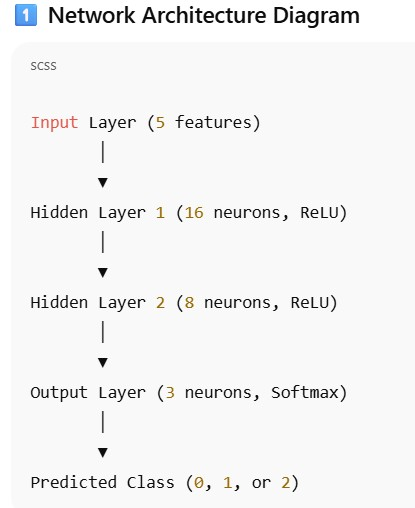                 


ClassIndexProbability                                                            	   
0 (rice)	    0.1

1 (wheat)	    0.7

2 (maize)	    0.2

np.argmax([0.1, 0.7, 0.2]) = 1
So the Predicted Class = 1 → "wheat" (using the mapping from LabelEncoder).

## 6. Evaluate the Model

In [ ]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss: {test_loss * 100:.2f}%")

# 7.Convert the Model to TensorFlow Lite

Why This is Important

Edge Devices Limitation

Microcontrollers and Raspberry Pi cannot run full Keras/TensorFlow models efficiently.

TFLite Advantages

Smaller file size → saves memory.

Optimized for low-power, low-compute devices.

Supports integer quantization for even faster inference.

Deployment

This .tflite file is what you load on the Arduino or Raspberry Pi to make predictions in real-time.


In [ ]:
# Convert the model to TensorFlow Lite format
#tf.lite.TFLiteConverter is a special tool from TensorFlow that converts models into a lightweight format for edge devices.
#from_keras_model(model) Takes your trained Keras model (model) as input. Prepares it for conversion to TFLite format.

converter = tf.lite.TFLiteConverter.from_keras_model(model)
#converter.convert() actually performs the conversion.The output tflite_model is a binary object containing the model in TensorFlow Lite format.
#TFLite models are much smaller and faster than full Keras models.They are suitable for microcontrollers and low-memory devices.

tflite_model = converter.convert()

# Save the TFLite model
with open('crop_model.tflite', 'wb') as f:
    f.write(tflite_model)
#with open('crop_model.tflite', 'wb') as f: Opens a new file named crop_model.tflite in write-binary mode (wb).
#The with statement ensures the file is properly closed after writing.f.write(tflite_model)
#Writes the binary TFLite model into the file.Now you have a physical .tflite file that can be copied to Raspberry Pi, Arduino, or other edge devices.

# 8. Test the TFLite Model

In [ ]:
# Load the TFLite model
#tf.lite.Interpreter is the TFLite tool to run inference with TFLite models.
#model_path='crop_model.tflite' → Specifies the TFLite model file you saved earlier.
#The interpreter is like a mini-engine that knows how to run the model on your device.

interpreter = tf.lite.Interpreter(model_path='crop_model.tflite')

#TensorFlow Lite models work with tensors (arrays of numbers).allocate_tensors() reserves memory for input and output tensors.
#Think of it as setting up the workspace for the model before running predictions.

interpreter.allocate_tensors()

# Get input and output details
#input_details → Information about what input the model expects: shape, data type, etc.
#output_details → Information about what the model outputs.
#This is necessary because TFLite models need exact shapes and data types.

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()


# Prepare a sample input
#X_test[0] → Take the first sample from the test set.np.expand_dims(..., axis=0) → Adds a batch dimension.
#TFLite expects input shape like (1, num_features) even for a single sample.
#.astype(np.float32) → Converts data to 32-bit float, which is required by TFLite.

sample_input = np.expand_dims(X_test[0], axis=0).astype(np.float32)

# Set the input tensor
#set_tensor(...) → Feed the sample input into the model.input_details[0]['index'] → Index of the input tensor in the model.
#Think of this as placing the sample on the model’s input table.
interpreter.set_tensor(input_details[0]['index'], sample_input)

# Run inference
#invoke() → Runs the model computation (forward pass) on the input.The model processes the input through all layers and produces output.
#Think of this as asking the model to make a prediction.

interpreter.invoke()

# Get the output
#get_tensor(...) → Retrieves the output values from the model.
#For a classification model with 3 classes, output will look like:


output = interpreter.get_tensor(output_details[0]['index'])
predicted_class = np.argmax(output)

print(f"Predicted Class: {predicted_class}, Actual Class: {y_test.iloc[0]}")


#9. Plot Training History

In [ ]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()


**Understanding the Model**

Model Architecture: The model consists of two hidden layers with 16 and 8 neurons, respectively, and an output layer with 3 neurons (corresponding to 3 crop types). The 'relu' activation function is used for hidden layers, and 'softmax' is used for the output layer to handle multi-class classification.

Training Process: The model is trained using the Adam optimizer and sparse categorical cross-entropy loss function, suitable for multi-class classification tasks.

TensorFlow Lite Conversion: After training, the model is converted to TensorFlow Lite format to enable deployment on edge devices with limited compute and memory resources.

**Raspberry Pi** → Use if you need Python, moderate compute, larger models.

**Arduino** → Use for tiny sensors, low power, extremely small models (TinyML).
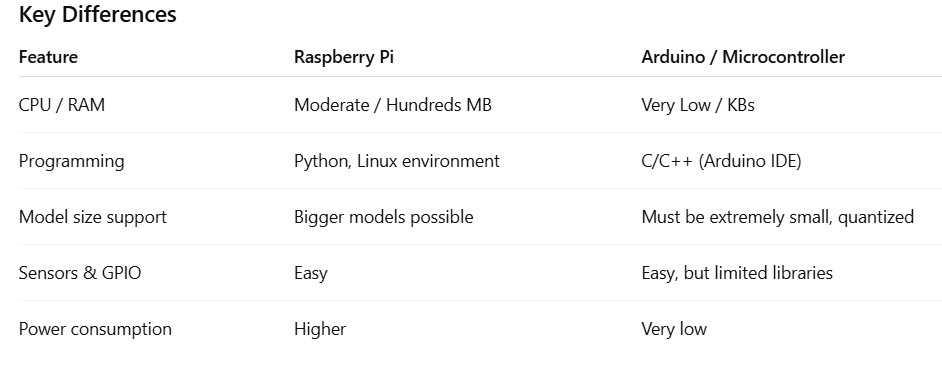

# TinyML Deployment Steps:
Raspberry Pi

Overview:
Full Linux computer (Raspberry Pi 4/3/Zero, etc.).

Runs standard Python, TensorFlow, and other libraries.

Can handle slightly larger ML models compared to microcontrollers.

Has USB, Wi-Fi, GPIO pins to connect sensors (soil moisture, temperature, humidity).

1. Install Python and TensorFlow Lite:

sudo apt update
sudo apt install python3-pip
pip3 install tflite-runtime

2.Copy your .tflite model to the Raspberry Pi.
3.Use a Python script to load and run the model:
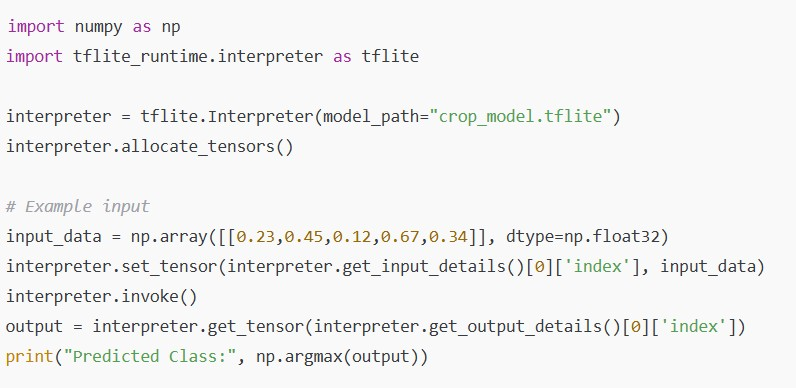                                                                                                                                                           
   4.Connect sensors (soil moisture, temperature) via GPIO and feed real-time readings to the model.

# Predict Crop from User Input

In [ ]:

# Feature order should match the dataset
feature_names = ['N (Nitrogen)', 'P (Phosphorus)', 'K (Potassium)', 'temperature', 'humidity', 'ph', 'rainfall']

print("\n🔹 Enter sensor readings manually (sample shown below):")
print("   For Example → N=29, P=30, K=31, temperature=29, humidity=70.0, ph=6.8, rainfall=200\n")

user_input = []

# Take input for each feature
for feature in feature_names:
    value = float(input(f"Enter value for {feature}: "))
    user_input.append(value)

# Convert to array and scale
user_input = np.array(user_input).reshape(1, -1)
user_input_scaled = scaler.transform(user_input)

# Convert to float32 for TensorFlow Lite
user_input_scaled = user_input_scaled.astype(np.float32)

# Set input tensor
interpreter.set_tensor(input_details[0]['index'], user_input_scaled)

# Run inference
interpreter.invoke()

# Get output prediction
output = interpreter.get_tensor(output_details[0]['index'])
predicted_class = np.argmax(output)
predicted_label = label_encoder.inverse_transform([predicted_class])[0]

print("\n🌾 Predicted Crop Recommendation:")
print(f"👉 {predicted_label}")
